# 22_因果机器学习-因果效应模型的评价与验证

## Notebook 使用说明

这是因果学习系列的第 17 份，也是“22. 因果机器学习”的第 7 份。建议先阅读《03. 双重机器学习与交互回归模型》《04. 条件平均处理效应与元学习器》和《05. DR-Learner与R-Learner》。本篇需要 NumPy、pandas、Matplotlib、SciPy、scikit-learn 和 statsmodels：`python -m pip install numpy pandas matplotlib scipy scikit-learn statsmodels`。

主线依据参考资料 [2] 第 15.2、15.3 节，顺序是独立评分、模型比较与组合，再到 BLP 异质性检验、校准和 uplift。本文的 $X$ 对应书中的完整调整变量 $Z$；$T$ 对应 $D$，$\Gamma$ 对应其双重稳健伪结局 $Y(\eta)$。本篇不再比较谁能画出最复杂的效应曲线，而是检查已训练模型在新样本上是否有依据。

小表、主模拟、重复抽样和两道练习是另设的教学构造，不复现书中的 401(k) 图表。真实数据部分只使用第十份笔记已核对的 LaLonde 实验样本：445 人，不含外部观察性对照。该数据快照已嵌入本文件并附校验，不需要前面笔记或额外数据文件。[1，第 3.4 节；6]

默认主样本为 6,000 人，按 50%／25%／25% 分为训练、选择和最终测试集；另做两种样本量下各 100 次完整流程模拟、各 400 次已知辅助函数的覆盖率实验，以及 600 次选择后检验实验。所有曲线的阈值都在测试集之外确定。输出与图形已保存，重新运行请使用 Restart Kernel and Run All Cells。版本中几处公式的实现口径在相应段落和文末说明，不将实现补充混作原书结论。

In [1]:
# 环境初始化：不访问网络；数据模拟和嵌入快照均可离线运行。
import os
import sys
import tempfile
import base64
import gzip
import hashlib
from io import StringIO
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display
import scipy
from scipy.special import expit
from scipy.stats import norm, chi2
from scipy.optimize import minimize
import sklearn
from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression, LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import StratifiedKFold
import statsmodels
import statsmodels.api as sm
from threadpoolctl import threadpool_limits

%matplotlib inline

_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei",
                        "SimHei", "Noto Sans CJK SC", "Noto Sans CJK JP"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 100, "figure.max_open_warning": 30})
pd.set_option("display.max_columns", 13)
pd.set_option("display.width", 150)
_thread_limit = threadpool_limits(limits=1)

SEED_DATA = 42
SEED_SPLIT = 2026
SEED_REPEAT = 2027
SEED_COVERAGE = 2028
SEED_SELECT = 2029
SEED_BAND = 2030
SEED_REAL = 2031
SEED_LEARNER = 99
N_MAIN = 6000
N_FOLDS = 3
N_REPEATS = 100
SAMPLE_SIZES = (1200, 4800)
N_COVERAGE = 400
COVERAGE_SIZES = (400, 1600)
N_SELECTION = 600
N_GAUSSIAN = 4999
Q_GRID = np.linspace(0.1, 0.9, 9)
CLIP = 0.01
Z_CRIT = norm.ppf(0.975)
X_COLS = ["X1", "X2", "X3"]
METHODS = ("常数", "T-线性", "DR-线性", "DR-二次", "DR-提升树")

if min(N_REPEATS, N_COVERAGE, N_SELECTION) < 2:
    raise ValueError("独立重复次数至少为 2。")
print(f"Python {sys.version.split()[0]}")
print(f"NumPy {np.__version__} | pandas {pd.__version__} | Matplotlib {plt.matplotlib.__version__}")
print(f"SciPy {scipy.__version__} | scikit-learn {sklearn.__version__} | statsmodels {statsmodels.__version__}")

Python 3.13.5
NumPy 2.3.5 | pandas 2.2.3 | Matplotlib 3.10.8
SciPy 1.17.0 | scikit-learn 1.8.0 | statsmodels 0.14.6


前面几篇在模拟里知道真实效应，所以可以计算预测误差。真实研究没有这列答案。把模型自己的两种预测相减，再用这个差去“验证”同一个模型，只是在检查它能否复述自己。

本篇把三个问题分开：模型的效应数值是否准确，能否将不同效应的人分开，以及按预测排序是否有助于优先安排处理。这三个问题相关，但答案不必相同。

## 理论基础

### 1. 没有个人效应标签，怎样比较模型？

目标仍是 $\tau(x)=E[Y(1)-Y(0)\mid X=x]$。在一致性、无干扰、给定完整 $X$ 后的条件可忽略性及重叠条件下，$\tau(x)=\mu_1(x)-\mu_0(x)$。这些识别条件并不会因为换成独立测试集就得到验证。[1，第 2、10 章]

记已经训练好的模型为 $f(x)$。理想的函数误差是

$$
R(f)=E[(f(X)-\tau(X))^2].
$$

我们不能在真实数据上直接算它，但可以构造

$$
\Gamma=\mu_1(X)-\mu_0(X)
+\frac{T\{Y-\mu_1(X)\}}{e(X)}
-\frac{(1-T)\{Y-\mu_0(X)\}}{1-e(X)}.
$$

已知真实辅助函数时，$E[\Gamma\mid X]=\tau(X)$，因此

$$
L_{\rm DR}(f)=E[(\Gamma-f(X))^2]
=R(f)+E[\operatorname{Var}(\Gamma\mid X)].
$$

最后一项对所有候选模型相同，所以两模型的 DR 损失之差等于真实函数误差之差。损失本身却不等于 CATE 的 MSE；更不能将其平方根直接称为个人效应的预测 RMSE。[2，式 (15.2.2)–(15.2.7)]

下面用三个特征层、两种处理和两种等概率噪声构成 12 行总体支持表。每一行带有概率，表示一种可能的观测，不是同时观测了某个人的两种潜在结局。

In [2]:
# 这张小表完整枚举有限总体分布，因而能核对期望，而不依赖抽样近似。
strata = pd.DataFrame({"层": ["低", "中", "高"], "p_x": [0.25, 0.50, 0.25],
                       "e": [0.2, 0.5, 0.8], "mu0": [1., 2., 4.],
                       "tau": [-1., 1., 3.]})
small_rows = []
for row in strata.itertuples(index=False):
    for t in (0, 1):
        for noise in (-0.5, 0.5):
            y = row.mu0 + t * row.tau + noise
            gamma = row.tau + (t / row.e - (1-t) / (1-row.e)) * noise
            small_rows.append([row.层, t, y, row.tau, row.e, gamma,
                               row.p_x * (row.e if t else 1-row.e) / 2])
small = pd.DataFrame(small_rows, columns=["层", "T", "Y", "tau", "e", "Gamma", "概率"])
display(small.round(4))
small_ate = np.dot(strata.p_x, strata.tau)
small_predictions = {"真函数": small.tau.to_numpy(),
                     "放大并平移": 2 * small.tau.to_numpy() + 1,
                     "只报总体均值": np.full(len(small), small_ate)}
small_loss = []
for name, pred in small_predictions.items():
    risk = np.dot(small.概率, (pred-small.tau)**2)
    loss = np.dot(small.概率, (pred-small.Gamma)**2)
    small_loss.append([name, risk, loss, loss-risk])
small_loss = pd.DataFrame(small_loss, columns=["模型", "真实函数MSE", "DR损失", "共同噪声项"])
display(small_loss.round(5))
assert np.isclose(small.概率.sum(), 1)
assert np.allclose(small_loss["共同噪声项"], small_loss["共同噪声项"].iloc[0])

,层,T,Y,tau,e,Gamma,概率
0,低,0,0.5,-1.0,0.2,-0.375,0.100
1,低,0,1.5,-1.0,0.2,-1.625,0.100
2,低,1,-0.5,-1.0,0.2,-3.500,0.025
3,低,1,0.5,-1.0,0.2,1.500,0.025
4,中,0,1.5,1.0,0.5,2.000,0.125
5,中,0,2.5,1.0,0.5,0.000,0.125
6,中,1,2.5,1.0,0.5,0.000,0.125
7,中,1,3.5,1.0,0.5,2.000,0.125
8,高,0,3.5,3.0,0.8,5.500,0.025
9,高,0,4.5,3.0,0.8,0.500,0.025


,模型,真实函数MSE,DR损失,共同噪声项
0,真函数,0.0,1.28125,1.28125
1,放大并平移,6.0,7.28125,1.28125
2,只报总体均值,2.0,3.28125,1.28125


即使第一行模型完全等于真实函数，DR 损失仍不为零。比较第二列与第三列的差，而不是给损失设置一个脱离结局单位的“及格线”。

### 2. 比较用同一批人的逐行损失差

对两个固定模型 $f,g$，定义

$$
d_i=(\widehat\Gamma_i-f(X_i))^2-(\widehat\Gamma_i-g(X_i))^2
=(f(X_i)-g(X_i))\{f(X_i)+g(X_i)-2\widehat\Gamma_i\}.
$$

计算 $\widehat\Delta=\overline d$ 及 $\widehat{\mathrm{SE}}=\operatorname{sd}(d)/\sqrt n$，再构造大样本区间。$\Delta<0$ 表示 $f$ 更好。不能把两个损失当作独立均值来相加方差，因为同一个人的 $\widehat\Gamma_i$ 同时进入两项。[2，定理 15.2.1]

原书的推断还要求评分用的辅助函数足够准确，并对两模型的分离程度作出条件。交叉拟合只处理数据复用，不保证这些条件自动成立。两个模型预测完全相同时，逐行差全为零；这不是获得了一个无限精确的优越性检验。

### 3. 训练、选择、测试是三种职责

| 数据 | 允许做什么 | 不用于什么 |
|---|---|---|
| 训练集 | 拟合候选效应模型；内部交叉拟合辅助预测 | 对最终表现作定论 |
| 选择集 | 比较候选；选择组合权重；确定分组阈值 | 给被选中模型作未经调整的最终检验 |
| 测试集 | 对已固定的模型、阈值和比较做验证 | 再挑模型、调阈值或校准后回报同一组结果 |

本篇在训练集上拟合评分辅助模型，预测选择集；模型选定后，用训练与选择集的并集重新拟合评分辅助模型，只为构造测试集的 $\widehat\Gamma$，不再改动候选 CATE 模型。这两种辅助训练安排均见书中说明。[2，正文第 419、428–429 页]

## 完整案例一：训练、选择与独立验证

### 1. 数据与划分

令三个 $X_j$ 独立服从 $U(-1,1)$，

$$
\begin{aligned}
e(X)&=\operatorname{expit}(0.7X_1+0.6X_2-0.3X_3),\\
\mu_0(X)&=2+2X_2+0.8X_3^2+0.5X_1X_2,\\
\tau(X)&=0.6+1.2X_1+0.8(X_1^2-1/3)+0.5X_2,\\
Y(t)&=\mu_0(X)+t\tau(X)+0.7(1+0.3X_1^2)\varepsilon_t.
\end{aligned}
$$

噪声独立标准正态，且给定 $X$ 后，处理独立于两种噪声。总体 ATE 为 0.6。候选模型和评分函数只接收观测列，真值单独保存。

In [3]:
def vector(x, name="数组"):
    v = np.asarray(x, dtype=float)
    if v.ndim != 1 or v.size < 2 or not np.isfinite(v).all():
        raise ValueError(f"{name}须为至少两个有限数的一维数组。")
    return v


def mean_ci(values, alpha=0.05):
    v = vector(values)
    if not 0 < alpha < 1:
        raise ValueError("alpha 须在 (0,1) 内。")
    estimate = v.mean()
    se = v.std(ddof=1) / np.sqrt(len(v))
    z = norm.ppf(1-alpha/2)
    return {"估计": estimate, "SE": se, "下限": estimate-z*se, "上限": estimate+z*se}


def paired_loss(gamma, f, g):
    """返回 f 减 g 的配对损失差推断，不把两个损失当作独立样本。"""
    gamma, f, g = [vector(v) for v in (gamma, f, g)]
    if not gamma.shape == f.shape == g.shape:
        raise ValueError("伪结局和两组预测必须逐行对齐。")
    difference = (f-g) * (f+g-2*gamma)
    result = mean_ci(difference)
    rms = np.sqrt(np.mean((f-g)**2))
    scale = max(1.0, np.sqrt(np.mean(f**2)), np.sqrt(np.mean(g**2)))
    result["p值"] = (2*norm.sf(abs(result["估计"]/result["SE"]))
                     if result["SE"] > 1e-14 and rms > 1e-10*scale else np.nan)
    result["预测差RMS"] = rms
    return result


def display_p_table(frame, p_columns, digits=4):
    table = frame.round(digits).copy()
    for column in p_columns:
        table[column] = frame[column].map(lambda p: "不可检验" if not np.isfinite(p)
                                         else ("<1e-300" if p == 0 else f"{p:.3g}"))
    display(table)


def make_data(n, seed):
    if not isinstance(n, (int, np.integer)) or n < 30:
        raise ValueError("样本量须为至少 30 的整数。")
    rng = np.random.default_rng(seed)
    x = rng.uniform(-1, 1, size=(n, 3))
    x1, x2, x3 = x.T
    e = expit(0.7*x1 + 0.6*x2 - 0.3*x3)
    mu0 = 2 + 2*x2 + 0.8*x3**2 + 0.5*x1*x2
    tau = 0.6 + 1.2*x1 + 0.8*(x1**2-1/3) + 0.5*x2
    sigma = 0.7*(1+0.3*x1**2)
    y0 = mu0 + sigma*rng.normal(size=n)
    y1 = mu0 + tau + sigma*rng.normal(size=n)
    t = (rng.uniform(size=n) < e).astype(int)
    frame = pd.DataFrame(x, columns=X_COLS)
    frame["T"], frame["Y"] = t, np.where(t == 1, y1, y0)
    truth = pd.DataFrame({"tau": tau, "e": e, "mu0": mu0, "mu1": mu0+tau,
                          "Y0": y0, "Y1": y1})
    return frame, truth


def split_three(n, seed, train_fraction=0.5, score_fraction=0.25):
    if min(train_fraction, score_fraction) <= 0 or train_fraction+score_fraction >= 1:
        raise ValueError("须为训练、选择和测试都保留正比例样本。")
    order = np.random.default_rng(seed).permutation(n)
    a, b = int(n*train_fraction), int(n*(train_fraction+score_fraction))
    parts = (order[:a], order[a:b], order[b:])
    if min(map(len, parts)) < 10:
        raise ValueError("每份数据至少保留 10 行。")
    assert len(np.unique(np.concatenate(parts))) == n
    return parts


observed, truth = make_data(N_MAIN, SEED_DATA)
i_train, i_score, i_test = split_three(N_MAIN, SEED_SPLIT)
train, score, test = [observed.iloc[i].copy() for i in (i_train, i_score, i_test)]
split_table = pd.DataFrame([
    [name, len(part), int(part["T"].sum()),
     int((1-part["T"]).sum())]
    for name, part in [("训练", train), ("选择", score), ("最终测试", test)]
], columns=["职责", "人数", "处理组", "对照组"])
display(split_table.round(3))
display(train.head(6).round(3))

,职责,人数,处理组,对照组
0,训练,3000,1530,1470
1,选择,1500,732,768
2,最终测试,1500,738,762


,X1,X2,X3,T,Y
1206,-0.359,0.929,0.244,0,3.259
2348,0.924,0.925,-0.236,1,6.156
4461,-0.951,0.318,-0.137,0,3.094
1629,0.390,-0.212,0.999,0,1.510
3448,-0.217,0.676,0.089,0,3.419
5787,-0.918,-0.590,-0.768,0,1.006


### 2. 把伪结局的来源写清楚

训练集内部做三折交叉拟合，构造用于 DR-Learner 的标签。每一折单独拟合标准化、结果模型与评分模型；每一行恰好作为留出行一次。

主模拟的结果模型使用二次特征加 Ridge，评分使用线性 Logistic。它们与本例生成式相容，但模拟真值没有传给模型。固定的惩罚是教学配置，不使用测试集调参。`known_randomization=False` 时预测的是个体评分；真实试验部分将改用训练样本中的处理比例。

In [4]:
def feature_matrix(frame):
    cols = [c for c in frame.columns if c not in ("T", "Y")]
    x = frame[cols].to_numpy(float)
    if x.ndim != 2 or x.shape[1] == 0 or not np.isfinite(x).all():
        raise ValueError("特征须为有限的二维数值矩阵。")
    return x


def regression_model(degree=2, alpha=1.0):
    return make_pipeline(PolynomialFeatures(degree=degree, include_bias=False),
                         StandardScaler(), Ridge(alpha=alpha))


def fit_nuisance(frame, degree=2, randomized=False):
    x, t, y = feature_matrix(frame), frame["T"].to_numpy(), vector(frame.Y)
    if not np.isin(t, [0, 1]).all() or min(np.sum(t == 0), np.sum(t == 1)) < 5:
        raise ValueError("辅助训练中两种处理至少各有 5 行。")
    m0 = regression_model(degree).fit(x[t == 0], y[t == 0])
    m1 = regression_model(degree).fit(x[t == 1], y[t == 1])
    if randomized:
        propensity = float(t.mean())
    else:
        propensity = make_pipeline(StandardScaler(), LogisticRegression(
            C=1000.0, max_iter=2000, tol=1e-9)).fit(x, t)
    return {"m0": m0, "m1": m1, "propensity": propensity,
            "columns": [c for c in frame.columns if c not in ("T", "Y")]}


def predict_nuisance(model, frame, clip=CLIP):
    if not 0 < clip < 0.5:
        raise ValueError("clip 须在 (0,0.5) 内。")
    x = frame[model["columns"]].to_numpy(float)
    if not np.isfinite(x).all():
        raise ValueError("待预测特征含非有限数。")
    e_model = model["propensity"]
    if isinstance(e_model, float):
        raw_e = np.full(len(x), e_model)
    else:
        index1 = np.flatnonzero(e_model.classes_ == 1).item()
        raw_e = e_model.predict_proba(x)[:, index1]
    return pd.DataFrame({"mu0": model["m0"].predict(x), "mu1": model["m1"].predict(x),
                         "e": np.clip(raw_e, clip, 1-clip), "raw_e": raw_e}, index=frame.index)


def dr_signal(frame, pred):
    if not frame.index.equals(pred.index):
        raise ValueError("辅助预测与观测行索引不一致。")
    t, y = frame["T"].to_numpy(), frame.Y.to_numpy(float)
    m0, m1, e = [pred[c].to_numpy(float) for c in ("mu0", "mu1", "e")]
    if not np.isin(t, [0, 1]).all() or not np.isfinite(np.c_[y, m0, m1, e]).all():
        raise ValueError("处理须为 0/1，结局与辅助预测须为有限数。")
    if np.any((e <= 0) | (e >= 1)):
        raise ValueError("不能用 0 或 1 的评分作分母。")
    return m1-m0 + t*(y-m1)/e - (1-t)*(y-m0)/(1-e)


def crossfit_nuisance(frame, seed=SEED_SPLIT, degree=2, randomized=False, n_folds=N_FOLDS):
    if not 2 <= n_folds <= np.bincount(frame["T"].to_numpy(int), minlength=2).min():
        raise ValueError("每种处理的样本数须不少于折数，折数至少为 2。")
    splitter = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    out = pd.DataFrame(np.nan, index=frame.index, columns=["mu0", "mu1", "e", "raw_e"])
    visits = np.zeros(len(frame), dtype=int)
    fold_id = np.zeros(len(frame), dtype=int)
    audit = []
    for k, (fit_idx, hold_idx) in enumerate(splitter.split(frame, frame["T"]), 1):
        assert np.intersect1d(fit_idx, hold_idx).size == 0
        fitted = fit_nuisance(frame.iloc[fit_idx], degree, randomized)
        out.iloc[hold_idx] = predict_nuisance(fitted, frame.iloc[hold_idx]).to_numpy()
        visits[hold_idx] += 1
        fold_id[hold_idx] = k
        audit.append([k, len(fit_idx), len(hold_idx), int(frame.iloc[fit_idx]["T"].sum()),
                      int(frame.iloc[hold_idx]["T"].sum())])
    assert np.all(visits == 1) and np.isfinite(out.to_numpy()).all()
    return out, fold_id, audit


oof, oof_fold, fold_audit = crossfit_nuisance(train)
gamma_train = dr_signal(train, oof)
display(pd.DataFrame(fold_audit, columns=["折", "训练行", "留出行", "训练处理行", "留出处理行"]))
preview = train[["T", "Y"]].join(oof[["mu0", "mu1", "e"]])
preview["折"], preview["Gamma"] = oof_fold, gamma_train
display(preview.head(8).round(4))
print("训练 OOF 评分被截断的行数：", int((oof.e != oof.raw_e).sum()))

,折,训练行,留出行,训练处理行,留出处理行
0,1,2000,1000,1020,510
1,2,2000,1000,1020,510
2,3,2000,1000,1020,510


,T,Y,mu0,mu1,e,折,Gamma
1206,0,3.2588,3.9636,4.1497,0.5569,2,1.7767
2348,1,6.1557,4.2428,6.9120,0.7953,1,1.7183
4461,0,3.0942,2.7105,2.5357,0.3721,1,-0.7858
1629,0,1.5099,2.3636,3.2126,0.4801,3,2.4911
3448,0,3.4188,3.4162,3.7521,0.5620,2,0.3300
5787,0,1.0057,1.5100,1.1025,0.2936,2,0.3064
3381,0,1.5565,2.5950,2.4660,0.3106,2,1.3775
3404,0,2.3613,2.4593,2.2284,0.3151,1,-0.0877


训练 OOF 评分被截断的行数： 0


### 3. 先拟合少量候选，再给它们打分

保留五个候选：训练集 AIPW 均值构成的常数、两组线性回归构成的 T-Learner，以及最终回归分别为线性、二次和提升树的 DR-Learner。它们共享同一份训练集，不共享测试标签。

评分阶段只需要候选预测矩阵与一列 $\widehat\Gamma$，不依赖模型内部结构。同样的接口也可以评价上一篇的因果森林。

相对常数模型的归一化 DR 分数写成

$$
S(f)=\frac{\widehat L_{\rm DR}(f_c)-\widehat L_{\rm DR}(f)}
{\widehat L_{\rm DR}(f_c)}.
$$

它可能为负。分母仍含伪结局噪声，所以它不是“解释了多少比例的真实效应异质性”。[2，式 (15.2.16)]

In [5]:
def fit_candidates(frame, gamma, compact=False):
    x, t, y = feature_matrix(frame), frame["T"].to_numpy(), frame.Y.to_numpy(float)
    gamma = vector(gamma)
    if len(gamma) != len(frame):
        raise ValueError("DR 标签长度不符。")
    models = {"常数": {"kind": "constant", "value": float(gamma.mean())},
              "T-线性": {"kind": "T",
                         "m0": regression_model(1).fit(x[t == 0], y[t == 0]),
                         "m1": regression_model(1).fit(x[t == 1], y[t == 1])},
              "DR-线性": {"kind": "DR", "model": regression_model(1).fit(x, gamma)}}
    if not compact:
        models["DR-二次"] = {"kind": "DR", "model": regression_model(2).fit(x, gamma)}
        models["DR-提升树"] = {"kind": "DR", "model": HistGradientBoostingRegressor(
            max_iter=100, learning_rate=0.06, max_leaf_nodes=7, min_samples_leaf=30,
            l2_regularization=1.0, early_stopping=False, random_state=SEED_LEARNER).fit(x, gamma)}
    columns = [c for c in frame.columns if c not in ("T", "Y")]
    for model in models.values():
        model["columns"] = columns
    return models


def predict_candidates(models, frame):
    if not models:
        raise ValueError("没有可用于预测的候选模型。")
    columns = next(iter(models.values()))["columns"]
    x = frame[columns].to_numpy(float)
    if not np.isfinite(x).all():
        raise ValueError("待预测特征含非有限数。")
    predictions = {}
    for name, model in models.items():
        if model["kind"] == "constant":
            predictions[name] = np.full(len(x), model["value"])
        elif model["kind"] == "T":
            predictions[name] = model["m1"].predict(x)-model["m0"].predict(x)
        else:
            predictions[name] = model["model"].predict(x)
    return pd.DataFrame(predictions, index=frame.index)


def loss_table(gamma, predictions, reference="常数"):
    g = vector(gamma)
    if len(predictions) != len(g) or reference not in predictions:
        raise ValueError("预测行数或参考模型不符。")
    loss = ((predictions.to_numpy()-g[:, None])**2).mean(axis=0)
    table = pd.DataFrame({"DR损失": loss}, index=predictions.columns)
    lref = table.loc[reference, "DR损失"]
    table["相对常数分数"] = (lref-loss)/lref if lref > 0 else np.nan
    return table


models = fit_candidates(train, gamma_train)
pred_score = predict_candidates(models, score)
scorer_score = fit_nuisance(train)
eta_score = predict_nuisance(scorer_score, score)
gamma_score = dr_signal(score, eta_score)
score_loss = loss_table(gamma_score, pred_score)
display(score_loss.round(5))

,DR损失,相对常数分数
常数,3.34577,0.00000
T-线性,2.77116,0.17174
DR-线性,2.74884,0.17841
DR-二次,2.67860,0.19941
DR-提升树,2.74194,0.18048


下面只根据 DR 损失选择，不根据哪条预测最接近模拟真值选择。冻结权重后再打开模拟真值，比较两种损失差。两条线不要求逐点相等：前面的等式是总体结论，而选择集有限，辅助函数也由数据估计。

### 4. 选择一个模型，或组合已有预测

除了最小损失的单一候选，再计算两个组合。凸组合要求权重非负且和为 1；Q-aggregation 在组合损失之外，加上按权重平均的候选损失：

$$
\widehat w_Q=\arg\min_{w_j\ge0,\,\sum_jw_j=1}
\left[\frac1{n_s}\sum_i\left(\widehat\Gamma_i-\sum_jw_jf_j(X_i)\right)^2
+\sum_jw_j\widehat L_{\rm DR}(f_j)\right].
$$

这是原书式 (15.2.19) 的等权两项形式；不另加截距，不将普通凸回归称为 Q-aggregation。理论界需要原书所列条件，不承诺每份数据中组合都赢。[2，式 (15.2.18)–(15.2.19)]

本篇预先指定最终验证 Q 组合。单一赢家与凸组合用于对照，不看测试结果再决定换成哪一个。

选择集单一赢家： DR-二次


,凸组合,Q组合
常数,0.04384,0.0
T-线性,0.00000,0.0
DR-线性,0.00000,0.0
DR-二次,0.95616,1.0
DR-提升树,0.00000,0.0


冻结的校准切点： [-0.0754  0.3445  1.2004]
最终验证对象：Q组合；另作预先指定的 2f+1 与 -f 教学对照。


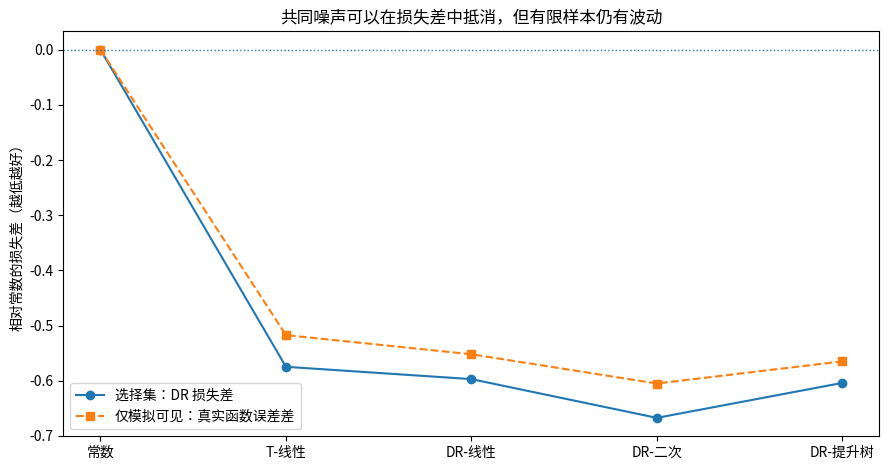

In [6]:
def stack_weights(predictions, gamma, q_penalty=False):
    """在固定候选预测的单纯形上，最小化凸组合或 Q-aggregation 目标。"""
    p = np.asarray(predictions, dtype=float)
    g = vector(gamma)
    if p.ndim != 2 or p.shape[0] != len(g) or p.shape[1] < 1 or not np.isfinite(p).all():
        raise ValueError("候选预测矩阵必须有限，且逐行对应标签。")
    m = p.shape[1]
    gram, cross = p.T @ p/len(g), p.T @ g/len(g)
    individual_loss = ((p-g[:, None])**2).mean(axis=0)
    # 目标中与 w 无关的常数可以删去，不改变最优解。
    penalty = individual_loss if q_penalty else np.zeros(m)
    def objective(w):
        return float(w @ gram @ w - 2*cross @ w + penalty @ w)
    def gradient(w):
        return 2*gram @ w - 2*cross + penalty
    result = minimize(objective, np.full(m, 1/m), jac=gradient, method="SLSQP",
                      bounds=[(0., 1.)]*m,
                      constraints={"type": "eq", "fun": lambda w: w.sum()-1,
                                   "jac": lambda w: np.ones(m)},
                      options={"ftol": 1e-11, "maxiter": 1000})
    if not result.success or abs(result.x.sum()-1) > 1e-7 or result.x.min() < -1e-8:
        raise RuntimeError(f"组合优化失败：{result.message}")
    # 仅消除边界求解的舍入误差。
    w = np.maximum(result.x, 0)
    w[w < 1e-10] = 0.0  # 数值零须精确置零，否则会给常数模型制造虚假的排序。
    return w/w.sum()


winner = score_loss["DR损失"].idxmin()
w_convex = stack_weights(pred_score.to_numpy(), gamma_score)
w_q = stack_weights(pred_score.to_numpy(), gamma_score, q_penalty=True)
weight_table = pd.DataFrame({"凸组合": w_convex, "Q组合": w_q}, index=pred_score.columns)
print("选择集单一赢家：", winner)
display(weight_table.round(5))
selected_score = pred_score.to_numpy() @ w_q
# 所有阈值、变换与对照都在读取测试结局前固定。
calibration_cuts = np.unique(np.quantile(selected_score, [0.25, 0.50, 0.75]))
calibration_cuts = calibration_cuts[(calibration_cuts > selected_score.min()) &
                                    (calibration_cuts < selected_score.max())]
print("冻结的校准切点：", np.round(calibration_cuts, 4))
print("最终验证对象：Q组合；另作预先指定的 2f+1 与 -f 教学对照。")

# 真值仅用于事后教学核对，不参与 choose/stack 的任何输入。
true_score_risk = ((pred_score.to_numpy()-truth.loc[score.index, "tau"].to_numpy()[:, None])**2).mean(axis=0)
fig, ax = plt.subplots(figsize=(9, 4.8))
pos = np.arange(len(models))
ax.plot(pos, score_loss["DR损失"]-score_loss.loc["常数", "DR损失"], "o-", label="选择集：DR 损失差")
ax.plot(pos, true_score_risk-true_score_risk[0], "s--", label="仅模拟可见：真实函数误差差")
ax.axhline(0, linestyle=":", linewidth=1)
ax.set(xticks=pos, xticklabels=list(models), ylabel="相对常数的损失差（越低越好）",
       title="共同噪声可以在损失差中抵消，但有限样本仍有波动")
ax.legend()
fig.tight_layout()
plt.show()

### 5. 打开最终测试集

到这里才用测试结局构造验证信号。下面的损失差仍按“待评模型减常数模型”定义。点区间是各自的 95% 区间；表中另外对预先列出的非恒定比较给出 Holm 调整的双侧 p 值，避免把多个普通检验当成一个检验。

同时列出事实结局 RMSE、处理概率 Brier 与评分范围，用于检查评分辅助模型。它们不是反事实误差，也不能证明伪结局没有偏差。

归一化分数与检验回答不同问题：分数略高并不必然足以拒绝“与常数同样好”。测试集也不是外部队列；这里检查的是同分布新样本表现。

,估计,SE,下限,上限,p值,预测差RMS,Holm_p
T-线性,-0.50395,0.09144,-0.68317,-0.32473,3.56e-08,0.93448,3.56e-08
DR-线性,-0.54087,0.07971,-0.69710,-0.38464,1.16e-11,0.81075,5.79e-11
DR-二次,-0.57720,0.08661,-0.74695,-0.40746,2.65e-11,0.85610,1.06e-10
DR-提升树,-0.54361,0.08650,-0.71315,-0.37407,3.29e-10,0.85762,6.58e-10
凸组合,-0.58262,0.08298,-0.74526,-0.41998,2.2e-12,0.81857,1.32e-11
Q组合,-0.57720,0.08661,-0.74695,-0.40746,2.65e-11,0.85610,1.06e-10


测试集 AIPW 平均效应与普通 95% 区间： {'估计': np.float64(0.5878), 'SE': np.float64(0.0471), '下限': np.float64(0.4955), '上限': np.float64(0.6802)}


事实结局RMSE     0.7817
处理概率Brier    0.2323
最小评分         0.1903
最大评分         0.8316
截断行数         0.0000
最大绝对DR信号     8.3664
Name: 测试评分辅助诊断, dtype: float64

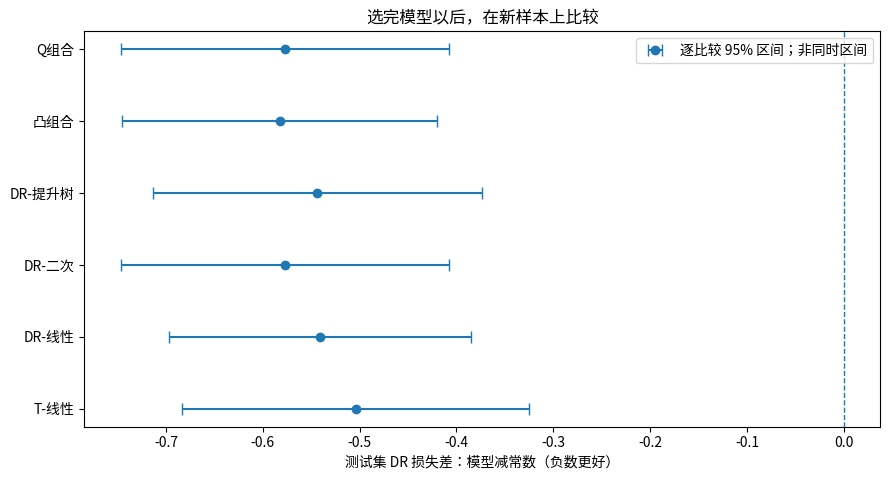

In [7]:
def holm_adjust(pvalues):
    p = np.asarray(pvalues, dtype=float)
    if p.ndim != 1 or np.any(np.isfinite(p) & ((p < 0) | (p > 1))):
        raise ValueError("p 值须在 [0,1] 内；不可检验项用 NaN。")
    adjusted = np.full_like(p, np.nan)
    valid = np.flatnonzero(np.isfinite(p))
    order = valid[np.argsort(p[valid], kind="stable")]
    if len(order):
        adjusted[order] = np.minimum(1, np.maximum.accumulate((len(order)-np.arange(len(order)))*p[order]))
    return adjusted


pred_test = predict_candidates(models, test)
train_score = pd.concat([train, score])
scorer_test = fit_nuisance(train_score)
eta_test = predict_nuisance(scorer_test, test)
gamma_test = dr_signal(test, eta_test)
pred_test["凸组合"] = pred_test[list(models)].to_numpy() @ w_convex
pred_test["Q组合"] = pred_test[list(models)].to_numpy() @ w_q
pred_test["单一赢家"] = pred_test[winner]
f_test = pred_test["Q组合"].to_numpy()

test_rows = {name: paired_loss(gamma_test, pred_test[name], pred_test["常数"])
             for name in ["T-线性", "DR-线性", "DR-二次", "DR-提升树", "凸组合", "Q组合"]}
test_comparison = pd.DataFrame(test_rows).T
test_comparison["Holm_p"] = holm_adjust(test_comparison["p值"])
display_p_table(test_comparison, ["p值", "Holm_p"], digits=5)
print("测试集 AIPW 平均效应与普通 95% 区间：", {k: round(v, 4) for k, v in mean_ci(gamma_test).items()})
factual_prediction = np.where(test["T"].to_numpy() == 1, eta_test.mu1, eta_test.mu0)
scorer_diagnostics = pd.Series({
    "事实结局RMSE": np.sqrt(np.mean((test.Y.to_numpy()-factual_prediction)**2)),
    "处理概率Brier": np.mean((test["T"].to_numpy()-eta_test.e.to_numpy())**2),
    "最小评分": eta_test.e.min(), "最大评分": eta_test.e.max(),
    "截断行数": int((eta_test.e != eta_test.raw_e).sum()),
    "最大绝对DR信号": np.max(np.abs(gamma_test))}, name="测试评分辅助诊断")
display(scorer_diagnostics.round(4))

fig, ax = plt.subplots(figsize=(9, 4.9))
ypos = np.arange(len(test_comparison))
ax.errorbar(test_comparison["估计"], ypos, xerr=Z_CRIT*test_comparison.SE,
            fmt="o", capsize=4, label="逐比较 95% 区间；非同时区间")
ax.axvline(0, linestyle="--", linewidth=1)
ax.set(yticks=ypos, yticklabels=test_comparison.index,
       xlabel="测试集 DR 损失差：模型减常数（负数更好）", title="选完模型以后，在新样本上比较")
ax.legend()
fig.tight_layout()
plt.show()

### 6. BLP：有异质性信号，不等于效应尺度正确

在测试集回归 $\widehat\Gamma$ 对 $(1,f(X))$：

$$
\widehat\Gamma_i=a+b f(X_i)+u_i,
\qquad b\longrightarrow
\frac{\operatorname{Cov}(\tau(X),f(X))}{\operatorname{Var}(f(X))}.
$$

$b\ne0$ 是模型捕捉到相关异质性信号的证据；$b<0$ 则方向相反。理想的线性校准是 $a=0,b=1$。拒绝 $b=0$，与不能拒绝 $(a,b)=(0,1)$，不是同一个结论。[2，式 (15.3.1)]

这里使用未中心化预测，便于直接检验 $(0,1)$。若把预测中心化，截距点估计变成 $\overline\Gamma$，但此时不能再拿截距为零作为校准目标。常数模型的预测没有变异，不能估计该斜率。

下面按预先约定比较 $f$、$2f+1$ 与 $-f$，不是根据测试结果重新训练模型。使用 HC1 稳健协方差；系数检验是正态近似，联合校准检验是二自由度 Wald 检验。[3]

In [8]:
def blp_test(gamma, prediction):
    g, f = vector(gamma), vector(prediction)
    if g.shape != f.shape or f.std() < 1e-12:
        raise ValueError("预测须逐行对齐且具有非零变异，常数模型不能做 BLP 斜率检验。")
    x = np.column_stack([np.ones(len(f)), f])
    fitted = sm.OLS(g, x).fit(cov_type="HC1", use_t=False)
    a, b = fitted.params
    cov = np.asarray(fitted.cov_params())
    delta = fitted.params-np.array([0., 1.])
    wald = float(delta @ np.linalg.solve(cov, delta))
    return {"截距a": a, "斜率b": b, "SE_b": fitted.bse[1],
            "b下限": b-Z_CRIT*fitted.bse[1], "b上限": b+Z_CRIT*fitted.bse[1],
            "p_b=0": 2*norm.sf(abs(b/fitted.bse[1])),
            "p_线性校准": chi2.sf(wald, 2)}, fitted


blp_models = {"Q组合 f": f_test, "放大平移 2f+1": 2*f_test+1, "反向 -f": -f_test}
blp_rows = {name: blp_test(gamma_test, f)[0] for name, f in blp_models.items()}
blp_table = pd.DataFrame(blp_rows).T
display_p_table(blp_table, ["p_b=0", "p_线性校准"], digits=5)
# 正仿射变换保持排序，也保持检验斜率是否为零的 |z|。
assert np.array_equal(np.argsort(f_test), np.argsort(2*f_test+1))
assert np.isclose(blp_table.iloc[0]["p_b=0"], blp_table.iloc[1]["p_b=0"])

,截距a,斜率b,SE_b,b下限,b上限,p_b=0,p_线性校准
Q组合 f,0.05074,0.89409,0.05819,0.78003,1.00815,2.87e-53,0.191
放大平移 2f+1,-0.39630,0.44704,0.02910,0.39001,0.50407,2.87e-53,<1e-300
反向 -f,0.05074,-0.89409,0.05819,-1.00815,-0.78003,2.87e-53,<1e-300


默认运行中，Q 组合在测试集的 BLP 斜率约为 0.894，线性校准联合检验的 p 值约为 0.191；这表示没有足够证据拒绝线性校准，并不证明完全校准。将预测改成 $2f+1$ 后，斜率变为约 0.447，效应尺度明显失准，斜率是否为零的检验却不变。只报告异质性 p 值，会漏掉这个问题。修改配置后，以重新运行结果为准。

### 7. 校准：分组预测与分组效应是否对应？

校准要求 $E[Y(1)-Y(0)\mid f(X)=s]=s$。按已冻结的分位数切点形成组 $G_k$，在测试集分别算

$$
\widehat\theta_k=\frac{1}{n_k}\sum_{i\in G_k}\widehat\Gamma_i,
\qquad \widehat f_k=\frac{1}{n_k}\sum_{i\in G_k}f(X_i).
$$

图的横轴是 $\widehat f_k$，纵轴是 $\widehat\theta_k$。误差棒为组效应的逐点区间，不是整条 CATE 函数的同时置信带。[2，式 (15.3.3)、(15.3.8)–(15.3.9)]

检验校准差时，另对同一组的 $\widehat\Gamma_i-f(X_i)$ 求均值和标准误；不能把横轴均值当成无误差常数，直接照搬纵轴误差棒来检验差值。下面同时展示两种标准误。

代码还给出分组 CAL1、CAL2。上传稿式 (15.3.10)–(15.3.11) 用人数相乘后求和；本篇保留该总和，再除以测试人数报告平均量。它们只是分组近似，含抽样噪声，不是可直接观察的总体校准误差。

,组,n,n处理,平均预测,DR组效应,SE_组效应,校准差,SE_校准差,差下限,差上限
0,1,331,100,-0.3566,-0.2793,0.0914,0.0773,0.0910,-0.1011,0.2557
1,2,410,192,0.1119,0.1677,0.0763,0.0558,0.0761,-0.0934,0.2050
2,3,381,209,0.7328,0.6394,0.0760,-0.0934,0.0751,-0.2405,0.0538
3,4,378,237,1.8361,1.7509,0.1001,-0.0852,0.0998,-0.2809,0.1105


,CAL1人数总和,CAL2人数总和,平均CAL1,平均CAL2
Q组合,116.2457,9.3204,0.0775,0.0062
2f+1,2420.4088,5059.9155,1.6136,3.3733


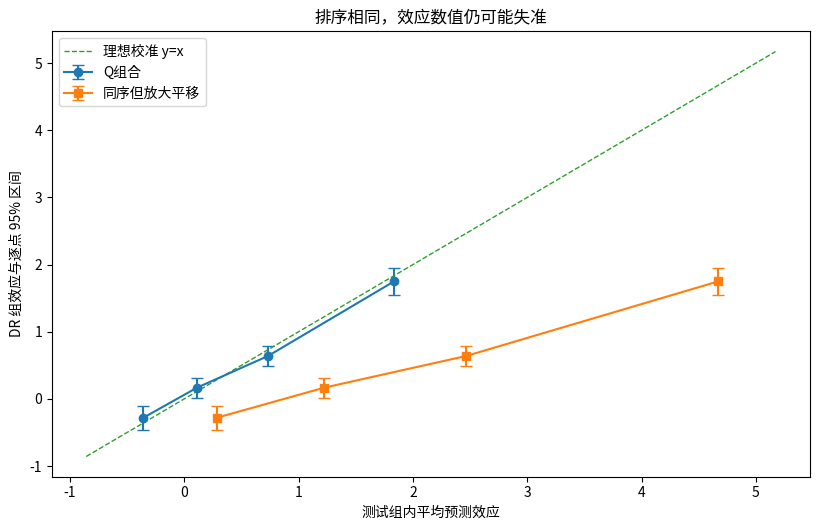

In [9]:
def calibration_table(gamma, prediction, cuts, treatment=None):
    g, f = vector(gamma), vector(prediction)
    cuts = np.asarray(cuts, float)
    if g.shape != f.shape or cuts.ndim != 1 or not np.isfinite(cuts).all() or np.any(np.diff(cuts) <= 0):
        raise ValueError("预测须对齐，有限切点须严格递增。")
    group = np.searchsorted(cuts, f, side="right")
    rows = []
    for k in range(len(cuts)+1):
        mask = group == k
        n_k = int(mask.sum())
        if n_k < 2:
            raise ValueError("某个冻结分组在测试集中不足 2 人，不能继续报告其区间。")
        gate = mean_ci(g[mask])
        gap = mean_ci(g[mask]-f[mask])
        rows.append([k+1, n_k, int(np.asarray(treatment)[mask].sum()) if treatment is not None else np.nan,
                     f[mask].mean(), gate["估计"], gate["SE"], gap["估计"], gap["SE"],
                     gap["下限"], gap["上限"]])
    table = pd.DataFrame(rows, columns=["组", "n", "n处理", "平均预测", "DR组效应", "SE_组效应",
                                        "校准差", "SE_校准差", "差下限", "差上限"])
    raw_cal1 = np.dot(table.n, np.abs(table.校准差))
    raw_cal2 = np.dot(table.n, table.校准差**2)
    metrics = {"CAL1人数总和": raw_cal1, "CAL2人数总和": raw_cal2,
               "平均CAL1": raw_cal1/len(g), "平均CAL2": raw_cal2/len(g)}
    return table, metrics, group


cal_f, cal_metrics, cal_groups = calibration_table(gamma_test, f_test, calibration_cuts, test["T"])
cal_bad, bad_metrics, _ = calibration_table(gamma_test, 2*f_test+1, 2*calibration_cuts+1, test["T"])
display(cal_f.round(4))
display(pd.DataFrame({"Q组合": cal_metrics, "2f+1": bad_metrics}).T.round(4))

fig, ax = plt.subplots(figsize=(8.3, 5.4))
for table, label, marker in [(cal_f, "Q组合", "o"), (cal_bad, "同序但放大平移", "s")]:
    ax.errorbar(table["平均预测"], table["DR组效应"], yerr=Z_CRIT*table["SE_组效应"],
                fmt=marker+"-", capsize=4, label=label)
limits = [min(cal_f["平均预测"].min(), cal_f["DR组效应"].min())-0.5,
          max(cal_bad["平均预测"].max(), cal_bad["DR组效应"].max())+0.5]
ax.plot(limits, limits, "--", linewidth=1, label="理想校准 y=x")
ax.set(xlabel="测试组内平均预测效应", ylabel="DR 组效应与逐点 95% 区间",
       title="排序相同，效应数值仍可能失准")
ax.legend()
fig.tight_layout()
plt.show()

### 8. Uplift：优先选择哪些人？

先在选择集上确定阈值 $c_q$，冻结规则 $h_q(X)=\mathbf1\{f(X)\ge c_q\}$。它大致对应预测最高的 $q$ 比例。测试集实际入选比例 $p_q=E[h_q(X)]$ 不一定恰为 $q$；不能悄悄在测试集重排，使人数重新满足配额。

按书中的定义，

$$
G_q=\frac{E[h_q\Gamma]}{E[h_q]},\quad
\mathrm{TOC}(q)=G_q-E[\Gamma],\quad
\mathrm{QINI}(q)=p_q\,\mathrm{TOC}(q).
$$

TOC 比较入选者平均效应与全体平均效应；QINI 比较以全体人口为分母的增量收益。这里“优先”默认结局越高越好。若结局是不良事件，需先明确收益方向。[2，式 (15.3.12)–(15.3.18)]

对离散预测，用边界上的随机化概率打破并列，实际计算其期望选择权重 $h_q\in[0,1]$，不为了排出顺序而借用结局。代码用选择集人数求这个概率；常数模型会得到 $h_q\equiv q$，TOC 与 QINI 都为零。[2，Remark 15.3.1]

#### 抽样误差需要计入测试集入选比例

本文按式 (15.3.17) 从测试集估计分母 $p_q$。对该比值作一阶展开，使用以下中心化影响值：

$$
\begin{aligned}
\phi_i^{\rm TOC}(q)&=\frac{h_{iq}}{\widehat p_q}(\widehat\Gamma_i-\widehat G_q)
 -(\widehat\Gamma_i-\widehat A),\\
\phi_i^{\rm QINI}(q)&=(h_{iq}-\widehat p_q)(\widehat\Gamma_i-\widehat A)
 -\widehat{\mathrm{QINI}}(q).
\end{aligned}
$$

这是本篇从比值与协方差定义推得的实现公式。它不是直接照录上传稿定理 15.3.1 中显示的 TOC 信号：两者相差
$-\widehat{\mathrm{TOC}}(q)(h_{iq}/\widehat p_q-1)$，对应估计分母的影响。练习一通过逐行微扰直接验证这一项。

共同的 $\widehat\Gamma$ 与全体均值会使不同 $q$ 的结果相关。我们从影响值估计完整协方差，用模拟高斯向量的最大绝对值确定同时临界值。该置信带只针对预先固定的九个阈值规则，不涵盖所有连续 $q$，也不计入重新训练模型或重新估计阈值的变动。[2，正文第 437–441 页]

,目标q,冻结阈值,边界概率,实际比例,TOC,SE_TOC
0,0.1,1.8922,0.0,0.1000,1.4601,0.1673
1,0.2,1.4137,0.0,0.2060,1.2617,0.0997
2,0.3,0.9720,0.0,0.3147,1.0080,0.0711
3,0.4,0.6005,0.0,0.4147,0.7906,0.0562
4,0.5,0.3436,0.0,0.5060,0.6051,0.0465
5,0.6,0.1392,0.0,0.6127,0.4344,0.0377
6,0.7,0.0071,0.0,0.7180,0.3246,0.0304
7,0.8,-0.1767,0.0,0.8267,0.1831,0.0227
8,0.9,-0.3695,0.0,0.9053,0.1111,0.0176


九条固定规则的双侧 95% 同时临界值：2.634；逐点临界值：1.960


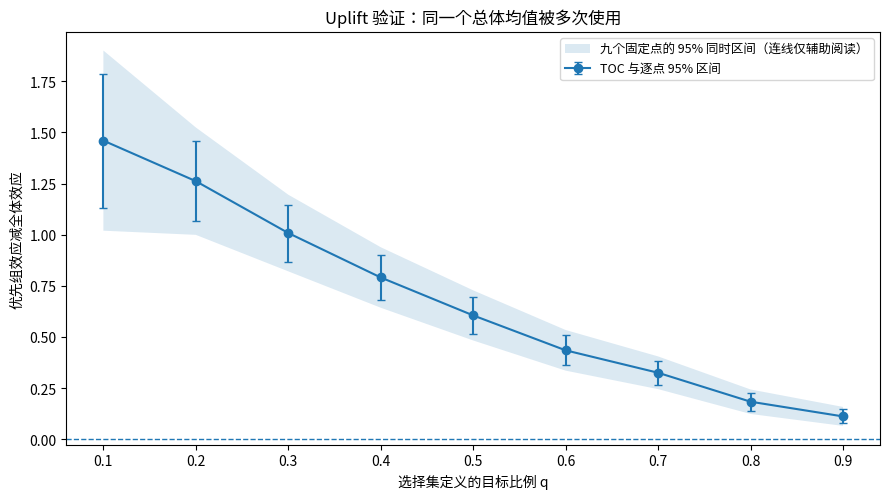

In [10]:
def threshold_policies(reference_scores, evaluation_scores, q_grid):
    """只从参考预测建立规则；评价样本不参与分位数或并列概率的估计。"""
    reference = vector(reference_scores, "阈值参考预测")
    evaluation = vector(evaluation_scores, "评价预测")
    q = np.asarray(q_grid, dtype=float)
    if q.ndim != 1 or not np.isfinite(q).all() or np.any((q <= 0) | (q > 1)):
        raise ValueError("目标比例须在 (0,1] 内。")
    sorted_ref = np.sort(reference)
    policies, records = [], []
    for fraction in q:
        if fraction == 1:
            policies.append(np.ones(len(evaluation)))
            records.append([fraction, -np.inf, 1.0, 1.0])
            continue
        # 用顺序统计量，不在线性插值后的空隙中制造“并列”。
        rank = max(0, min(len(reference)-1, int(np.ceil((1-fraction)*len(reference)))-1))
        cut = sorted_ref[rank]
        greater = np.mean(reference > cut)
        equal = np.mean(reference == cut)
        tie_probability = (fraction-greater)/equal
        if not -1e-10 <= tie_probability <= 1+1e-10:
            raise ArithmeticError("并列概率计算超出 [0,1]。")
        tie_probability = float(np.clip(tie_probability, 0, 1))
        h = (evaluation > cut).astype(float) + tie_probability*(evaluation == cut)
        policies.append(h)
        records.append([fraction, cut, tie_probability, h.mean()])
    return np.column_stack(policies), pd.DataFrame(records, columns=["目标q", "冻结阈值", "边界概率", "实际比例"])


def uplift_statistics(gamma, policies):
    """用随机分母的比值和协方差，计算固定规则的 TOC、QINI 与影响值。"""
    g = vector(gamma)
    h = np.asarray(policies, dtype=float)
    if h.ndim != 2 or h.shape[0] != len(g) or not np.isfinite(h).all() or np.any((h < 0) | (h > 1)):
        raise ValueError("策略矩阵须逐行对应伪结局，取值位于 [0,1]。")
    p = h.mean(axis=0)
    if np.any(p <= 0):
        raise ValueError("某条固定规则未选中任何测试样本，不能估计其组均值。")
    a = g.mean()
    gate = np.mean(h*g[:, None], axis=0)/p
    toc = gate-a
    qini = p*toc
    phi_toc = h/p*(g[:, None]-gate) - (g[:, None]-a)
    phi_qini = (h-p)*(g[:, None]-a)-qini
    assert np.allclose(phi_toc.mean(axis=0), 0, atol=1e-10)
    assert np.allclose(phi_qini.mean(axis=0), 0, atol=1e-10)
    # 协方差使用分母 n；与原书经验矩口径一致。
    cov_toc = phi_toc.T @ phi_toc/len(g)**2
    cov_qini = phi_qini.T @ phi_qini/len(g)**2
    return {"p": p, "ATE": a, "GATE": gate, "TOC": toc, "QINI": qini,
            "phi_TOC": phi_toc, "phi_QINI": phi_qini,
            "cov_TOC": cov_toc, "cov_QINI": cov_qini}


def simultaneous_critical(covariance, seed=SEED_BAND, draws=N_GAUSSIAN, alpha=0.05):
    cov = np.asarray(covariance, dtype=float)
    if cov.ndim != 2 or cov.shape[0] != cov.shape[1] or not np.isfinite(cov).all():
        raise ValueError("协方差须为有限方阵。")
    if draws < 100 or not 0 < alpha < 1 or not np.allclose(cov, cov.T):
        raise ValueError("模拟次数、显著性水平或协方差对称性不符。")
    if np.linalg.eigvalsh((cov+cov.T)/2).min() < -1e-9:
        raise ValueError("协方差不是半正定矩阵。")
    se = np.sqrt(np.maximum(np.diag(cov), 0))
    active = se > 1e-12
    if not active.any():
        return 0.0
    corr = cov[np.ix_(active, active)]/np.outer(se[active], se[active])
    values, vectors = np.linalg.eigh((corr+corr.T)/2)
    if values.min() < -1e-7:
        raise ValueError("协方差不是半正定矩阵。")
    root = vectors @ np.diag(np.sqrt(np.maximum(values, 0)))
    z = np.random.default_rng(seed).normal(size=(draws, len(values))) @ root.T
    return float(np.quantile(np.max(np.abs(z), axis=1), 1-alpha))


h_test, policy_audit = threshold_policies(selected_score, f_test, Q_GRID)
uplift = uplift_statistics(gamma_test, h_test)
critical_toc = simultaneous_critical(uplift["cov_TOC"])
se_toc = np.sqrt(np.diag(uplift["cov_TOC"]))
policy_audit["TOC"] = uplift["TOC"]
policy_audit["SE_TOC"] = se_toc
display(policy_audit.round(4))
print(f"九条固定规则的双侧 95% 同时临界值：{critical_toc:.3f}；逐点临界值：{Z_CRIT:.3f}")

fig, ax = plt.subplots(figsize=(9, 5.1))
ax.fill_between(Q_GRID, uplift["TOC"]-critical_toc*se_toc, uplift["TOC"]+critical_toc*se_toc,
                alpha=0.16, label="九个固定点的 95% 同时区间（连线仅辅助阅读）")
ax.errorbar(Q_GRID, uplift["TOC"], yerr=Z_CRIT*se_toc, fmt="o-", capsize=3,
            label="TOC 与逐点 95% 区间")
ax.axhline(0, linestyle="--", linewidth=1)
ax.set(xlabel="选择集定义的目标比例 q", ylabel="优先组效应减全体效应",
       title="Uplift 验证：同一个总体均值被多次使用")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

不要在九个普通区间中挑一个刚好越过零的点，再说“95% 置信地发现异质性”。同时区间允许在这九个预定点中查看，但其结论仍以识别假设和辅助估计质量为前提。

曲线面积也要保留点之间的协方差。下面只积分展示网格覆盖的 $[0.1,0.9]$ 区间，采用梯形权重；这不是书中从 0 到 1 的完整 AUTOC／AUQC。其标准误由 $w^\top\widehat\Sigma w$ 得到，不是将九个标准误平均。[2，式 (15.3.19) 及后续讨论]

再对 $2f+1$ 使用相同变换后的参考分数和阈值，QINI 应完全不变。将所有效应数值放大并平移，改善不了排序，也不能修好校准。

,曲线,"[0.1,0.9]离散面积",SE,下限,上限
0,TOC,0.5393,0.0364,0.4679,0.6107
1,QINI,0.1985,0.0134,0.1722,0.2248


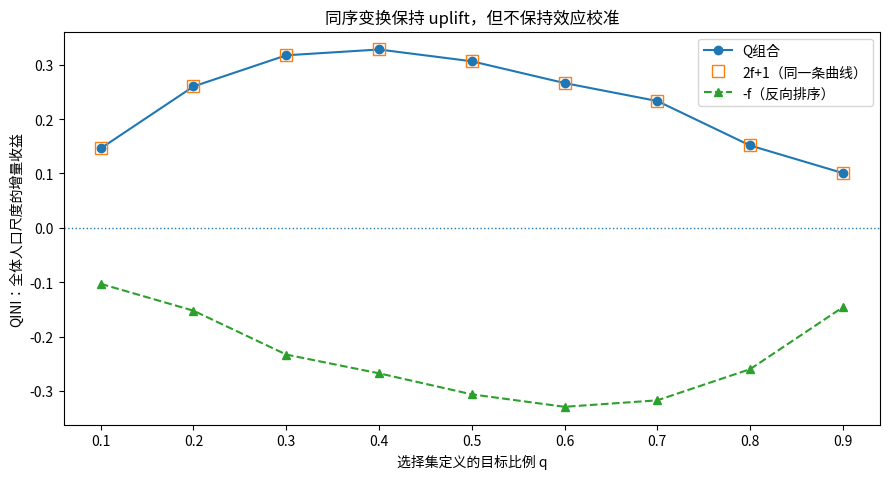

In [11]:
def trapezoid_weights(grid):
    q = np.asarray(grid, float)
    if q.ndim != 1 or len(q) < 2 or not np.isfinite(q).all() or np.any(np.diff(q) <= 0):
        raise ValueError("积分网格须至少有两个严格递增的有限点。")
    weight = np.zeros(len(q))
    weight[:-1] += np.diff(q)/2
    weight[1:] += np.diff(q)/2
    return weight


h_affine, _ = threshold_policies(2*selected_score+1, 2*f_test+1, Q_GRID)
h_reverse, _ = threshold_policies(-selected_score, -f_test, Q_GRID)
assert np.array_equal(h_test, h_affine)
uplift_affine = uplift_statistics(gamma_test, h_affine)
uplift_reverse = uplift_statistics(gamma_test, h_reverse)
area_weights = trapezoid_weights(Q_GRID)
area_rows = []
for metric in ("TOC", "QINI"):
    estimate = float(area_weights @ uplift[metric])
    se = np.sqrt(area_weights @ uplift["cov_"+metric] @ area_weights)
    area_rows.append([metric, estimate, se, estimate-Z_CRIT*se, estimate+Z_CRIT*se])
display(pd.DataFrame(area_rows, columns=["曲线", "[0.1,0.9]离散面积", "SE", "下限", "上限"]).round(4))

fig, ax = plt.subplots(figsize=(9, 4.9))
ax.plot(Q_GRID, uplift["QINI"], "o-", label="Q组合")
ax.plot(Q_GRID, uplift_affine["QINI"], "s", fillstyle="none", markersize=9, label="2f+1（同一条曲线）")
ax.plot(Q_GRID, uplift_reverse["QINI"], "^--", label="-f（反向排序）")
ax.axhline(0, linestyle=":", linewidth=1)
ax.set(xlabel="选择集定义的目标比例 q", ylabel="QINI：全体人口尺度的增量收益",
       title="同序变换保持 uplift，但不保持效应校准")
ax.legend()
fig.tight_layout()
plt.show()

## 完整案例二：重复整个选择流程

单次的最佳模型可能只是碰巧更适合当前选择集。下面在 1,200 人和 4,800 人两种总样本量下，各重新生成 100 份数据。每次重新划分、交叉拟合、训练候选、拟合评分辅助模型、选择赢家及组合，最后才在测试集上计算真值误差。

“本次候选中最好的真值 MSE”只作模拟参照，不能作为真实数据中的选择规则；组合也可能超过其中任何单个候选。这里展示平均测试 MSE 与 Monte Carlo 标准误，不把重复训练曲线的波动叫作个人效应置信区间。

,,平均MSE,重复间SD,MC_SE
总人数,模型,,,
1200,常数,0.6254,0.0439,0.0044
4800,常数,0.6191,0.0229,0.0023
1200,T-线性,0.0882,0.0230,0.0023
4800,T-线性,0.0776,0.0114,0.0011
1200,DR-线性,0.0771,0.0153,0.0015
4800,DR-线性,0.0610,0.0039,0.0004
1200,DR-二次,0.0552,0.0261,0.0026
4800,DR-二次,0.0114,0.0057,0.0006
1200,DR-提升树,0.1986,0.0403,0.0040


赢家编号,常数,T-线性,DR-线性,DR-二次,DR-提升树
总人数,,,,,
1200,0,17,23,58,2
4800,0,0,1,98,1


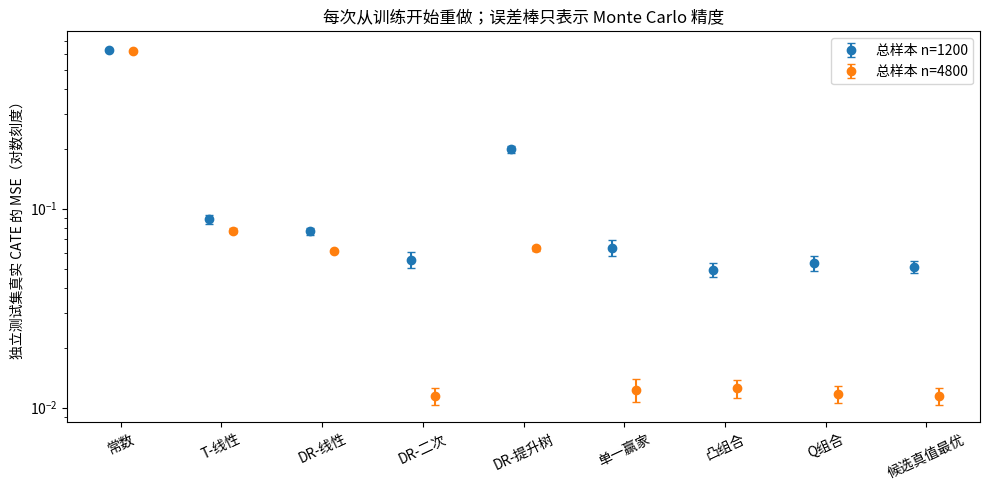

In [12]:
def run_selection_pipeline(n, seed):
    obs, truths = make_data(n, seed)
    ii = split_three(n, seed+100000)
    tr, sc, te = [obs.iloc[z].copy() for z in ii]
    oo, _, _ = crossfit_nuisance(tr, seed=seed+200000)
    gt = dr_signal(tr, oo)
    fitted = fit_candidates(tr, gt)
    ps = predict_candidates(fitted, sc)
    gs = dr_signal(sc, predict_nuisance(fit_nuisance(tr), sc))
    losses = ((ps.to_numpy()-gs[:, None])**2).mean(axis=0)
    best = int(np.argmin(losses))
    wc = stack_weights(ps.to_numpy(), gs)
    wq = stack_weights(ps.to_numpy(), gs, q_penalty=True)
    pt = predict_candidates(fitted, te).to_numpy()
    gt_eval = dr_signal(te, predict_nuisance(fit_nuisance(pd.concat([tr, sc])), te))
    target = truths.loc[te.index, "tau"].to_numpy()
    mse = ((pt-target[:, None])**2).mean(axis=0)
    row = {name: float(value) for name, value in zip(fitted, mse)}
    row.update({"单一赢家": float(mse[best]), "凸组合": float(np.mean((pt@wc-target)**2)),
                "Q组合": float(np.mean((pt@wq-target)**2)), "候选真值最优": float(mse.min()),
                "赢家编号": best, "选择集改善": float(losses[0]-losses[best]),
                "测试集改善": float(np.mean((gt_eval-pt[:, 0])**2-(gt_eval-pt[:, best])**2))})
    return row


repeat_records = []
for n in SAMPLE_SIZES:
    for r in range(N_REPEATS):
        row = run_selection_pipeline(n, SEED_REPEAT+n*10+r)
        repeat_records.append({"总人数": n, "重复": r, **row})
repeats = pd.DataFrame(repeat_records)
report_methods = [*METHODS, "单一赢家", "凸组合", "Q组合", "候选真值最优"]
repeat_summary = repeats.melt(id_vars=["总人数", "重复"], value_vars=report_methods,
                               var_name="模型", value_name="测试MSE").groupby(["总人数", "模型"], sort=False)["测试MSE"].agg(
                                   平均MSE="mean", 重复间SD="std")
repeat_summary["MC_SE"] = repeat_summary["重复间SD"]/np.sqrt(N_REPEATS)
display(repeat_summary.round(4))
display(pd.crosstab(repeats["总人数"], repeats["赢家编号"]).reindex(columns=range(len(METHODS)), fill_value=0).rename(
    columns=dict(enumerate(METHODS))))

fig, ax = plt.subplots(figsize=(10, 5))
xpos = np.arange(len(report_methods))
for shift, n in zip((-0.12, 0.12), SAMPLE_SIZES):
    values = repeats.loc[repeats["总人数"] == n, report_methods]
    ax.errorbar(xpos+shift, values.mean(), yerr=Z_CRIT*values.std(ddof=1)/np.sqrt(len(values)),
                fmt="o", capsize=3, label=f"总样本 n={n}")
ax.set_yscale("log")
ax.set(xticks=xpos, xticklabels=report_methods, ylabel="独立测试集真实 CATE 的 MSE（对数刻度）",
       title="每次从训练开始重做；误差棒只表示 Monte Carlo 精度")
ax.tick_params(axis="x", rotation=25)
ax.legend()
fig.tight_layout()
plt.show()

默认运行中，小样本有 58 次选择 DR-二次，另外 42 次选择了其他候选；大样本有 98 次选择 DR-二次。Q 组合平均测试 MSE 从约 0.053 降到 0.012，仍不保证逐次优于所有候选。

T-线性与 DR-线性都遗漏了二次效应；提升树虽能拟合更复杂的函数，却也可能把伪结局噪声学进去。评分与组合试图利用候选的差异，并不保证消除有限样本误差。这些数字只对应默认配置。

## 模型分析

### 1. 先单独检查验证公式的覆盖率

为避免将辅助学习误差与验证误差混在一起，下一段直接使用模拟里的真实辅助函数。它不是实际分析方案，而是验证公式的 oracle 实验。

固定两个候选 $f=\tau$、$g=2\tau+1$。它们的真实风险差为 $-E[(\tau+1)^2]$，可由生成式精确计算。Uplift 的排序规则另固定为 $X_1$，阈值 $1-2q$ 来自已知均匀分布，不估计分位数。因为主效应还依赖 $X_2$，这个排序不是完整 CATE 的理想排序。

每种测试样本量各做 400 次独立抽样，检查风险差区间、TOC 各点区间及九点同时区间。目标是固定规则在总体中的表现，不是当前测试样本的有限样本效应。

,风险差覆盖,逐点平均覆盖,逐点区间九点全覆盖,同时区间九点全覆盖,平均同时临界值,风险差估计
测试人数,,,,,,
400,0.925,0.9578,0.7775,0.9525,2.6292,-3.1909
1600,0.955,0.9447,0.7375,0.9475,2.6328,-3.1754


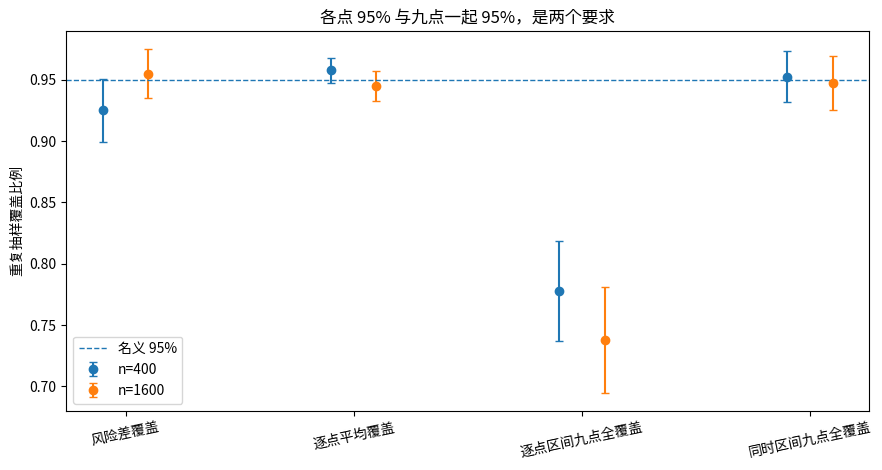

In [13]:
# E[tau]=0.6；相互独立且中心化的三项给出精确方差。
tau_variance = 1.2**2/3 + 0.8**2*(1/5-1/9) + 0.5**2/3
true_risk_difference = -(tau_variance + 1.6**2)
a_grid = 1-2*Q_GRID
true_toc = 1.2*(1-Q_GRID) + 0.8*(a_grid+a_grid**2)/3
coverage_rows = []
for n in COVERAGE_SIZES:
    for r in range(N_COVERAGE):
        obs_r, truth_r = make_data(n, SEED_COVERAGE+n*100+r)
        gamma_r = dr_signal(obs_r, truth_r[["mu0", "mu1", "e"]])
        effect = truth_r.tau.to_numpy()
        risk = paired_loss(gamma_r, effect, 2*effect+1)
        h_r = (obs_r.X1.to_numpy()[:, None] > a_grid).astype(float)
        stats = uplift_statistics(gamma_r, h_r)
        se = np.sqrt(np.diag(stats["cov_TOC"]))
        critical = simultaneous_critical(stats["cov_TOC"], seed=10000+r, draws=999)
        point_covered = np.abs(stats["TOC"]-true_toc) <= Z_CRIT*se
        simultaneous = np.abs(stats["TOC"]-true_toc) <= critical*se
        coverage_rows.append({"测试人数": n, "风险差覆盖": risk["下限"] <= true_risk_difference <= risk["上限"],
                              "逐点平均覆盖": point_covered.mean(), "逐点区间九点全覆盖": point_covered.all(),
                              "同时区间九点全覆盖": simultaneous.all(),
                              "平均同时临界值": critical, "风险差估计": risk["估计"]})
coverage = pd.DataFrame(coverage_rows)
display(coverage.groupby("测试人数").mean().round(4))

fig, ax = plt.subplots(figsize=(9, 4.8))
coverage_names = ["风险差覆盖", "逐点平均覆盖", "逐点区间九点全覆盖", "同时区间九点全覆盖"]
for shift, n in zip((-0.1, 0.1), COVERAGE_SIZES):
    block = coverage.loc[coverage["测试人数"] == n, coverage_names]
    ax.errorbar(np.arange(4)+shift, block.mean(),
                yerr=Z_CRIT*block.std(ddof=1)/np.sqrt(len(block)), fmt="o", capsize=3, label=f"n={n}")
ax.axhline(0.95, linestyle="--", linewidth=1, label="名义 95%")
ax.set(xticks=np.arange(4), xticklabels=coverage_names, ylabel="重复抽样覆盖比例",
       title="各点 95% 与九点一起 95%，是两个要求")
ax.tick_params(axis="x", rotation=12)
ax.legend()
fig.tight_layout()
plt.show()

默认运行中，九个逐点区间同时覆盖全部目标的比例约为 77.8% 与 73.8%；同时区间对应约为 95.3% 与 94.8%。风险差区间在 400 人时覆盖率为 92.5%，也不能只展示接近名义值的那一列。这不是逐点公式自相矛盾，而是所要求的事件和有限样本表现不同。即使使用同时区间，有限样本、正态近似和高斯临界值的模拟也会产生误差。

以上实验使用已知辅助函数，不能据此宣称实际学习后的所有检验都有 95% 覆盖率。特别是重叠不足、权重极端或评分模型错设时，同一套表格仍可能输出很小的 p 值。

### 2. 选择集被反复查看，会发生什么？

真实效应处处为零。预先给定 80 个互相独立的二元特征，每个特征都可被当成一个“高分／低分”的候选排序。对每个候选算高分与低分的 DR 信号差，再挑标准化差异最大的一个。

分别在挑选它的同一份数据和一份新的数据中检验该对比。候选数量依次为 1、5、20、80。这里的“同集拒绝率”是刻意错误的做法，用于说明选择后的检验问题；不是推荐的分析步骤。新测试集只验证选中的一个对比，不重新选择。

,同集检验,新集检验
候选数,,
1,0.0500,0.0533
5,0.2367,0.0517
20,0.6683,0.0450
80,0.9783,0.0550


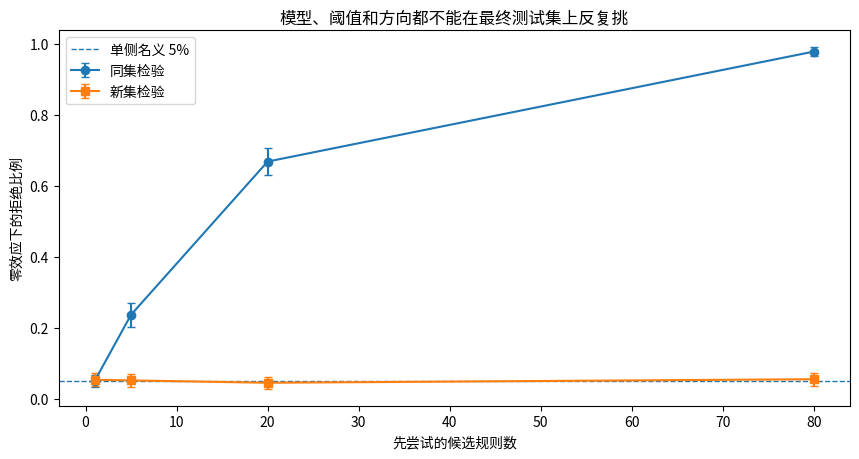

In [14]:
def binary_contrasts(gamma, group_matrix):
    g = vector(gamma)
    h = np.asarray(group_matrix, dtype=float)
    if h.ndim != 2 or len(h) != len(g) or not np.isin(h, [0, 1]).all():
        raise ValueError("分组矩阵须为逐行对齐的二元矩阵。")
    n1, n0 = h.sum(axis=0), (1-h).sum(axis=0)
    if np.any(np.minimum(n1, n0) < 2):
        raise ValueError("每种组别至少需要两行。")
    mean1, mean0 = g @ h/n1, g @ (1-h)/n0
    ss1 = g**2 @ h - n1*mean1**2
    ss0 = g**2 @ (1-h) - n0*mean0**2
    se = np.sqrt(np.maximum(ss1, 0)/(n1*(n1-1)) + np.maximum(ss0, 0)/(n0*(n0-1)))
    return mean1-mean0, se


select_rows = []
candidate_counts = (1, 5, 20, 80)
for r in range(N_SELECTION):
    rng = np.random.default_rng(SEED_SELECT+r)
    # 随机试验 e=1/2、mu0=mu1=0：真实 DR 信号为 2*(2T-1)*Y。
    x_s = rng.integers(0, 2, size=(300, 80))
    x_t = rng.integers(0, 2, size=(300, 80))
    gamma_s = 2*(2*rng.integers(0, 2, 300)-1)*rng.normal(size=300)
    gamma_t = 2*(2*rng.integers(0, 2, 300)-1)*rng.normal(size=300)
    ds, ses = binary_contrasts(gamma_s, x_s)
    dt, set_ = binary_contrasts(gamma_t, x_t)
    for m in candidate_counts:
        selected = int(np.argmax(ds[:m]/ses[:m]))
        select_rows.append({"候选数": m, "同集检验": ds[selected]/ses[selected] > norm.ppf(0.95),
                            "新集检验": dt[selected]/set_[selected] > norm.ppf(0.95)})
selection_experiment = pd.DataFrame(select_rows)
selection_rates = selection_experiment.groupby("候选数")[["同集检验", "新集检验"]].mean()
display(selection_rates.round(4))

fig, ax = plt.subplots(figsize=(8.7, 4.7))
for column, marker in [("同集检验", "o"), ("新集检验", "s")]:
    rate = selection_rates[column]
    se_mc = np.sqrt(rate*(1-rate)/N_SELECTION)
    ax.errorbar(selection_rates.index, rate, yerr=Z_CRIT*se_mc, fmt=marker+"-", capsize=3, label=column)
ax.axhline(0.05, linestyle="--", linewidth=1, label="单侧名义 5%")
ax.set(xlabel="先尝试的候选规则数", ylabel="零效应下的拒绝比例",
       title="模型、阈值和方向都不能在最终测试集上反复挑")
ax.legend()
fig.tight_layout()
plt.show()

默认配置中，尝试 80 个候选后，同集检验的拒绝率约为 97.8%，而新测试集约为 5.5%。同集检验随候选数增加而更容易“发现”不存在的差异。先选择，再留出新数据验证，才能将选择步骤与最后的检验分开。交叉拟合辅助模型并没有完成这一步。

## 完整案例三：在真实小样本中，允许得到不确定的结论

现在回到 LaLonde 实验数据。处理表示是否分配到培训，结局是 1978 年实际收入。[1，第 3.4 节] 本段只保留 185 位培训组与 260 位随机对照，使用与第十份笔记一致的八个处理前变量，不混入外部对照。

这不是书中第 15 章的实证复现，而是把本篇验证流程应用于第一本书的案例。收入除以 1,000，效应单位也随之变为千美元。445 人再分为训练、选择、测试，最后测试样本很小；只设置三个简单候选和两个预定分位数组，不把分析目标改成“总能发现异质性”。

按照独立样本工作模型做大样本验证。由于没有在此快照中读取原始试验方案中的分配概率，本段不将全样本处理比例冒充已知设计概率，而在每次辅助训练中用训练处理比例拟合截距型评分。该安排不等于复现完整随机化设计下的精确检验。数据重尾与小组人数也会影响正态近似。

In [15]:
# 完整实验数据快照；压缩只是为了使 Notebook 能作为单文件运行。
REAL_SHA256 = 'e7a54d9a8977793f078bf39e5ebe180a195ff7628585490539a1988f41d486d7'
REAL_GZIP_BASE64 = (
    'H4sIAAAAAAAC/41cS8/lOG7d57dcGCJFvdZ3n00CZDmo6f4waSSZGdTM/P8c+ruUKFu2C42q6gVly3wckkfU/eP31z/+9q+fv329'
    '/vnz68c/Xz/+8vX6+v1fv73+/L8/fvuf13//8Y+///jr6/9+/Pz5x9fvr7/+7fevv/z8+nr9/CqifyX9q/7bv//Hf/3pP0Og1/4/'
    'L3rF8iLCv+G1/72F/U9rEf8kE+cuzvxqu2xw0jG1tNVm0nE8HFK8C+//fcRZWmhbf7iMh/e9+KeXFPJGXTyNp8dXPUlzbVvpW8nz'
    'xo/CElLepEuXIR1XG8cfE61jF7zadJXCG2UTb34flM8qoSxb4I84Bf+N2Mjn2V2cWKhuZOLDmtQWX1mpxK11aWdMLIinvVAJTTbb'
    'Og1rUl3oe+iEZkOGk1NRLbFtpm0ahqTyKqcHx8Bxq+axlP03fh4+iTPX7lNUpq0svlFSpbGVOhn+/PCSW9zEpIcxZenfFGqQLX7E'
    'eRiT81q8SOlPZ5r2QjcK52FJgZzYc7toIhlxxi4s6x7E83OzhLq1Lu2MKattUGs0Np28kywUSEQ5bubf7MKyLeEnSxyf6YyZVltp'
    'tZUBVlwPbnhEK+xFuNuem3fD1dYzI9ZsMzE86KUBCosJ08Ozhy2js2V9yUkyp0Rbsk3HuFDJFGqpyCam7+iMGe6BLabpyWfRSLB7'
    'MWXHYUlhdcETsIUUUld2nEyZzl9JiMoe87Eu8NjDYGoEpfS9uLjMH6SiCVAAax2SZTbknW2EJsRcRDAn2ZJtW3iG42OgUaRaty4d'
    'vY+c8bWGTCNFicxo/P2FLvuVWrbWvzFNdj87a2zIUsmiWPKDVzmVlPtdO8nqJdudZLt3DkIcDpxM4SFZSwWGkKk5ORvep7E0zIf4'
    'XWihBt2GWSRN+fEWr5M8xBZHAQQbeqQ01VHnjaQWtlItyFP+ZbBJxZd/Z5tQyGVLVjCk6tOMnLZRuMrWuj7aAhGm2iWSPv0jnsNU'
    'GdE5WuBBm1gyzfSrfpfZ55i6yF8oL5p5U3bJMa2UJznnjbv4U82akHi5mfPl5Pcii/IC+ahXuDl7V11ap43yIpeHrTiVTHhaTqp2'
    'ks6IFopTCCTJWzHPK2FK5+dqC/VN27KhUiG/4ztEKOwRffHgjMKJe+YvUyjmuwc/RSJRy6ljdEneIpRO4i21OnC0HHH05NO11FFP'
    'ljKFwGIzNZdR7Zfqs9Gt+uZC9ewaHNFO9Uq/HkPxlJ0F3ZKhU6UHFY59VJ4gcoV7TBvZB9apUP10PxOyN0GVYFav8lDru40kL3qH'
    'HjVPe7iLqjp1jfXcHFfUNGyuVOvUDSzq6sKRxsPbofQ46qIqPJoFW/A2ufu+Rg9JDg1SGL1a41/OLS0+VOtOVB7qqtYQJp20aMN6'
    'Ig9PzgfnPHVGqY4c1Ir3zwVLIJWHv7U6JbgVvZEcX9GmquZOdRSCN8qZZuGMTt6MTY7DeShgyfM3eSXaGGhnrAmFJxNKTRtHk5aH'
    'AkgqyZa7eJoa+QXdg9a8gwE5BgeVcrv7yKeePwqMsfV9PNSl1BIa1mLSbVGLrfdBYaFs2ktwrmdp8iX62EYGDKKo+o5xRZBsWyGe'
    'N24vEEmbEikoDQQ1DLrW4BbFiw4QvfMGv0KXC5NCJ25nV3atsA8aHsQsmh5UQo0bejaxZRPGuqYt5hI2gGWMsmmt796UL0DuuAR9'
    'VqpjWVm8Sf/DxpBdtZJDL5SQzJR7MLt7rufUC8cCVEDxA23wlvsntRvuKWosoJ6oxNJLIuKr7iQpmYnoTgEgj2W50BZjX0ZTJTW3'
    '01mLKNQ4VCqlrgXmG+qloCxpsGorsXRIIscEnfhCW0El64fZimOONValRbgm2omKYEHickY9UEKjCIpazEC0UUPvXhHWSP7F4t1T'
    'QxaWlpca3ABejr2V2MkN4qvyKWUUN0j5LQKOUWS5va34vvGWjH5DoYnjcBtHE/GHkv1+T1MHKJqPgM3ISyk1/GPLPF004UbMsIim'
    'JoaHK3zjKWION/NGw0BUKKMv0ziI+7s05k0PjkHiEw6T9mgwaw4xFEvr5GmkfKwCKDbNevDCHLZoWedAJY23IMYIlQjE927whR4F'
    '2utflBa0mf5dETWxasShvyItVCMPb3D0UjzWupThqugHka5ceMdTNea+qFBEFCBt4x2xv6NeBJDBCOJNtr23IumUJzm2SUN1uB1M'
    'qdQyHgaHYI+oEg7q9n0BM+f9LVEdyiwkU5IfCkC3CLTBogodVOU6EExmI0dAzaU5ieAlFY9Cbcc+IhwLNRcTwilswHpBkAJLYabQ'
    'mQFybFRn3Hbn1myCNpZTU0z070lT3TkXZpwJlTLjZVC40Xok+aJgQPcCGIy6LKmiBaK9OvIE1bH9R7FTNhQWrSG95Gor6kUjjRDN'
    'G2pV3imASWvtJn64wETo/BmRzt0/0wwIQ9FJWzGgOxfkIPh90q8i84OZvjqgPNe4w0JE0wowtiU8mdR5QSza22KZINTyKysf09WQ'
    '4lpx+AwkLnxOA3Dha0uKqfMn5KmtKd9lzqi5BFWTHv3ASdS23JclX0vPaA/roqfWh8GJxFwuzZX9qPKA1sqiKMsbVI/DSummvI+M'
    'PgAIgHQcBlqletGYZEHmQbxFpGyFBugCabwva4sDsP2DArI9gCci+29TkeXpL3LatrIs5gYtQzma+00HjgSbTjWZFLGxSP0BEBwF'
    'GumokCdeU1w5B5zC1kXP27CJEtHt9OjLK2DYOWcqAfJYptxE8t8kEzLOvorMqqdMXjxdAGkraG0Bs1LxhqYvbyVvfWPHA0EPpiki'
    'rWg84ltax4RcDkhi7HkSiCOYkyCTIEkWoKr0VXWdg9BwQHFa0eEfpPCmtWnf3Xzg69QmuWoYQbgqRNJ+bmnoUMKa28mCxA9ISwU4'
    'j6xdkJlyL+7L1TETQoe+l7WoqTwl5tHmFV4cTOqfqieBAAYsk60ixFQ9PdRLnDuW/m1IYKhlXuisAcsam9BHr6Ed4zbX0ELfmSXr'
    'UXzxjuFZt6lrRVqBVcu3nYApGfhaS9dGvqiDSFchX+SKoK3Zv+lYQn5Q6CUIKIbVS0gAZ41jjTBbVadT+rngKhWg2hj4h2Kgl4Ol'
    'nV70AZaCshEhWwUv0py9c/ufVTUcAsoTA1VLb3h2Qr26BYMIx87F6ehMm9BvEllJNARVatrq2LK5chjkfUxBwqZRn4AtGbik1Kvp'
    'r07s+YBx1G+B9SVApKC1IevBeF8lflV1qwrQVX1Z453RlNU8+IOaFlr/RBb8DzVR0uNdAJOeJX689m0TL29VQbxjS9427bKL5hV5'
    'hFSjvJSJxyHONwzF2yZdVJLWxH5RJZt06tKyZGGAwM3w8G2jLpcPb8z9kPxtoy77puVTJs9bSdm4krdNu6h0lBVbmNU7Ytd18w+X'
    'FSMKoLCHf/iS/eH53jLkjEir0+ZUFHuyiTtD1lvLkLOhzaLQWtLZsK24fSc6DAigrHevz5N+F5QiUTRy4W3TLR/9LsdVqEPv26Zb'
    'Pg56JqhbQw/azDPIGW9N/mmVGetHnJ312q2Ombzm2plxzjnV7nI8bCeycueCVNYfPZnvrOmoxy3Z3ILFf+FCOqHybn0jw4rasSzm'
    'Q0ogG5d622iLmTLcuBIX783lZBcn6eJvedadtJPhvofmoWA1AVORbcgALIYD3h1PbLOOfHQkjTQp5LyZ/Tw4NhMfhrw4WRU0I9FQ'
    'L0YfNDfHSm+barn2VCeaJtFFxESk69A/MU97vn1ymfZ7fjIDBzpIx+r3cWb40atA1V0Xzbv1cqoKPZiYHSVMW6HT09GI1oEiQpPZ'
    'F0Q8SinrQN821bLrpN6imcRFCEwP1pIjmbJlRtQ7i4uLRV7soaDp3cgiV7LXx1nZNSpx3dVRfrlAkOpVsbILC9vh2dvmWgyu77wp'
    'hWkTi7mCULU0N3HyX3hGEIlFhlcnnrLnoqBIeuRh207xIWbctsVnmNVponJ1ZpeUHj7SPThPqluUYjs70PXhbNgenlwfjIJykvPW'
    'ddfuizxUtvhCk87BFx4rMxbATXfUTA94nRNrM2Hic326GIVtkYxjedtoy7UdGa0Ab/3p8lBcDB3m5DeS7iTzQ40HbaPh6VsuC3+6'
    'ePKEqKt5xTEp/ba5FkPUVU1NrXRPLcH70x3mFTo46jWIFZ4+7k7BJfqnloXW0C1mC9gik/ev5kig457HSzqkz+Msoegxbza/KM6E'
    '66nnmCl2E5YyF52nrcfWieS3zbS89wOyVzzHi87yWclZ2kPKrfs0jm28hkXzMvm/1r9dmibr3Bmyss9GjjXoYVuQnmN/cnwoJN2T'
    'HxpFJzmMmMIKOpxoXpRLs723kpKVKnWVD9eFbH3Kh060LcBoGtJFNb1V84s2bCfLWMl6T6U3no18M7KoZGNpqftR48kx4nm8mBry'
    'oSmkPQQjq3Qy6GgyOccSaeB2/eFpAqbFCF3WKzPmSy0/pABGxt1C30zxzdQtnrb6UFQTZ7Hhj7dNt1zDb3+yTbdYUjwbx4nSpLwb'
    'h6Lwy2hKjqhZXpNJhfqh/5scWTPCldYP/uWChhxLE59Ey2P1jz7rMyz/JsfRrO9UQFVsB4tv8hzNfblLjqDhtGjcBWX3FotJ01O5'
    'MS5ovclTNPKwjej950xZVdIKgk1afITk1VBS7HQYOapGk9t5aLlEoGM2XVN+QDG36/JgFie6KmXWAeJJmno38/gmfmopJKZgt8Pe'
    '5FiatISKUhElBkTkaBr4c7pOP8Txng2LWTWcTVo8+bkYyauQNnN4iqbdzP2+ifOC6rjQ2y/3g+Tome9BpFOXIqVxDz1Hz8T46UvX'
    'HhHDL/tZnPjtFQUmNrv7JsfJLO/0UcrVxoXe5CiZ5cx90bNTMdyMMqPsmfwlGpHkiJl+n+VAiTebb31TnDjulS/ryT73zyx+46tL'
    'mvulqmjidSIiFkxVDG0ArmNn1uKJa28gyZEza+6fBdIWVkJPJwW1lPFsPvSP5w4P/V01e8pkz5W4arEYIshUjJYFHxzZLj+9SdKD'
    'iYDjIW794fmgxGsAcQTNfVFMjp+5n1Z+k+NmLnSBpsnO797k+Bm6JxjIcTN71JxPWJhoSD+ZkPZ7MKY2x8086MJRM+vrZU2Phi1i'
    'HDVDiqRHa6SgR6cmfLbdAXOoiR1JvikdozFcb7rOzN0psrTUDoanabLhnTIcL3Nh7ZK21JNQpvsHx3FI+ybHyjy5Ro4L5JhKNS6t'
    'jCfLvTY46CSOqTmne9fgCIfu+JufENXtuhyUd+JTBT0H9yfXX9fHUxCSTuLZiQKVMJvl5KQQ7y0kFXqIrKLXM4wtozKRpEN9SScp'
    'PvPYMWI7bFhd4sULECDaPn4uNOtBeH+JXOiGlHPMfNCPZ2r8WRjr/EP6EKySqedJx9Vw9dRO1F8l+J6+eeWCWM79K8pF35d0gOHz'
    'FW5LdT676pN/sQYHWeT21KbefPYHPZ6rLbsX1PlUeK7U9IA/tuLF7/g3IATSdvLifFEZHMfhhVEhGFFL9crUMC9aj6KDlZs2buhx'
    '+sT+m2Y65zi8V+KWgOcoRWR0UY7Xmef9kAZhjqZT1FtFpSc6jW+R4SmePqa9j0LrrL5OfRXZElpm2Yt4C1VH9ZyHMkX5dYleefWa'
    'C9fpdtnnjGWj1vfVbqivxFo96uDwznJ/lrSwYDjUTpl01KDoANVWit9XOxRN00AYXCDBwUoMnXQhRwDNrVHWETgd0q/A9+ZfcXc6'
    'qRBRdbxY/c3YempyUybuakKKdm+4qp8oZJ34zTrxDZBK0or9HgBW5RsEzVn2Sw3uJeXQsPhOsyQNLi9dL0jzGLKOqL6KzsW2aUk7'
    'cD3eo2rQwfComFVshujN4erMhCXuA2IVaCpjdhIr5mmQ8dE5AwuDnmlm1lHa2AQAk2wZX+QxaQGfo2Qdup+2F6rZjgLYT/lMp6VI'
    'evtgKzr977l3nUb7/JILlk2c/GGAHQ9FDOsQKVqcvr10sb1dXOfdOSKBx++jQAsxdsTSfGRSGkJfGQK9ZqEz2Tm2fsjH8xzQ8dJA'
    '1IDEtqV14ohDvQiBhKYButDxrX3oEJKtF/oc5pmEI55D84mcbT3nJL5Y5IwiQy/B7HOUdZ/+JyuVeB4QGhDATSc6NSXD41StOmhl'
    'NnIcVDwyEyg2smrN7Wym8V2AIp/uc/9Fzw2TXyJXJhUkMs02JWqIAneS9BN3prTmK6tO72e9BwS/gV4LFRrvyjd0D4A4wzfVVNFG'
    'fLGkXBx5SNRRQYYlwz71LOp41v8y1YvjJmYdLxF1gKADxajvilNGuyFseQ+i/EpKt/Ug4ukYzrFdherGaOFYry+iaQAwjgMXngeO'
    'fEggEqIosgBM0T20UrgXrsx8XfWz/tCVuwIA6cvq73NXB9WEziT4JVcDD1X2gWLW+5KsfjR4OeZpmCy7e4Jw0KrD/CkoOrjXXFHN'
    'FJL+spIWKTr/gH2rvczrHO8Vs58iSYKqF5EHVNTfZVJ0kD7FwXx1boDWlr7H+aFkvd9Q9VZEV3a7sJEOnKJ31AH9tIcIkQOhGNZs'
    'FwwpehUkCjw2+LCNdFHxiXqpfpYOUwZvJ8eSSZznj4MOHOvoctVrWCVptWgYFFeZwro7Uc6+TG+RRXbt4qI1hU96MV0oLMeov0ry'
    'knT69LzIrPvdq6QArdGGf7GyaXXYVVwujmvgPjAJ/EHJM63b0Ia4l1X/9cMyRHq9qWEVcjJSsrpg94LYbkbKkh4rN+/ZckVpl0zf'
    'd2c09hTuA5dOE7PQReYCjLCqDrG0GwdlSetzUiy8KMW/r65BbXrTFlbSykSHXGrPKn4KajqLRPUF/UUUCqFuSA3oKtFfmfc4tm26'
    'EBJbKjrdvK/SIKxOf450m5N/rRp7WKWmxRZjCdV9WT4MjPVlARkGjlH0xhPcr2QABPdl5TBHZCpBDch6Y6fqgfp3BYCaoG+yTlYb'
    'NyiT4nHBqqy3sV5lv1DSV7V1AdU475dCGukqV3tyCuep3737DYD2Ta8rK12dvuuoavjl6Lrzj+20qJldYITK/Xv8ONVEzlPUlmZf'
    'pVdB/dbiVSTaLUhkWg1Ft0QO6TKM5h91vZ6Z6bRDee0/2mddBzsir4/PkrukQbtpNNvH1Oe82Y9befJDf7Aq67s47qvc9spF1Y5E'
    'DujSWyBaDnrAS3W2qCmu6WXBuF8kFdKt5YZerW+trQ8h4Y1oD7JK6+0/PaiL9gNYb/aDWF17+7K0Z1e9Qxh5/70e0Z/k+n9u5aXW'
    'ZFMAAA=='
)

In [16]:
raw_data = gzip.decompress(base64.b64decode(REAL_GZIP_BASE64))
if hashlib.sha256(raw_data).hexdigest() != REAL_SHA256:
    raise ValueError("实验数据快照校验失败。")
real_raw = pd.read_csv(StringIO(raw_data.decode("utf-8")))
real_columns = ["age", "educ", "black", "hispan", "married", "nodegree", "re74", "re75"]
assert len(real_raw) == 445 and real_raw.treat.sum() == 185
assert real_raw.id.is_unique and not real_raw.isna().any().any()
real_frame = real_raw[real_columns].astype(float).copy()
real_frame["T"] = real_raw.treat.to_numpy(int)
real_frame["Y"] = real_raw.re78.to_numpy(float)/1000
r_train, r_score, r_test = split_three(len(real_frame), SEED_REAL, 0.6, 0.2)
rt, rs, re = [real_frame.iloc[i].copy() for i in (r_train, r_score, r_test)]
real_oof, _, _ = crossfit_nuisance(rt, seed=SEED_REAL, degree=1, randomized=True)
real_models = fit_candidates(rt, dr_signal(rt, real_oof), compact=True)
real_ps = predict_candidates(real_models, rs)
real_gs = dr_signal(rs, predict_nuisance(fit_nuisance(rt, degree=1, randomized=True), rs))
real_loss = loss_table(real_gs, real_ps)
real_w = stack_weights(real_ps.to_numpy(), real_gs, q_penalty=True)
real_reference = real_ps.to_numpy() @ real_w
# 只确定中位数切点，不能依据测试结果多次移动切点。
real_cut = np.unique(np.quantile(real_reference, [0.5]))
real_cut = real_cut[(real_cut > real_reference.min()) & (real_cut < real_reference.max())]
display(pd.DataFrame([[label, len(part), int(part["T"].sum())]
                      for label, part in [("训练", rt), ("选择", rs), ("测试", re)]],
                     columns=["职责", "人数", "培训人数"]))
display(real_loss.round(4))
display(pd.Series(real_w, index=real_ps.columns, name="冻结Q权重").round(4))
print("真实数据只含观测列；没有 CATE 真值列。")

,职责,人数,培训人数
0,训练,267,107
1,选择,89,40
2,测试,89,38


,DR损失,相对常数分数
常数,186.2132,0.0000
T-线性,193.5327,-0.0393
DR-线性,194.5825,-0.0449


常数       1.0
T-线性     0.0
DR-线性    0.0
Name: 冻结Q权重, dtype: float64

真实数据只含观测列；没有 CATE 真值列。


快照中的 `hispan`、`nodegree` 分别对应 Matching 文档中的 `hisp`、`nodegr`；本篇沿用第十份笔记的统一列名。

只使用冻结后的组合和切点进入测试步骤。小样本下，模型看起来有明显的预测起伏，不代表组间处理效应已经被可靠区分。

下面报告 Q 组合相对常数的配对损失差、BLP 检验和两组校准。若组合退化为常数，就明确跳过不可识别的 BLP 斜率，而不是报一个伪造的 p 值。所有区间都是此工作模型下的大样本近似；没有真实 CATE，因而不报告 PEHE、真值 MSE 或个人获益概率。

,估计,SE,下限,上限,p值,预测差RMS
Q组合减常数,0.0,0.0,0.0,0.0,不可检验,0.0


Q组合为常数：BLP 斜率没有可用的预测变异，未进行该检验。


,组,n,n处理,平均预测,DR组效应,SE_组效应,校准差,SE_校准差,差下限,差上限
0,1,89,38,1.7675,2.7078,1.5412,0.9403,1.5412,-2.0805,3.961


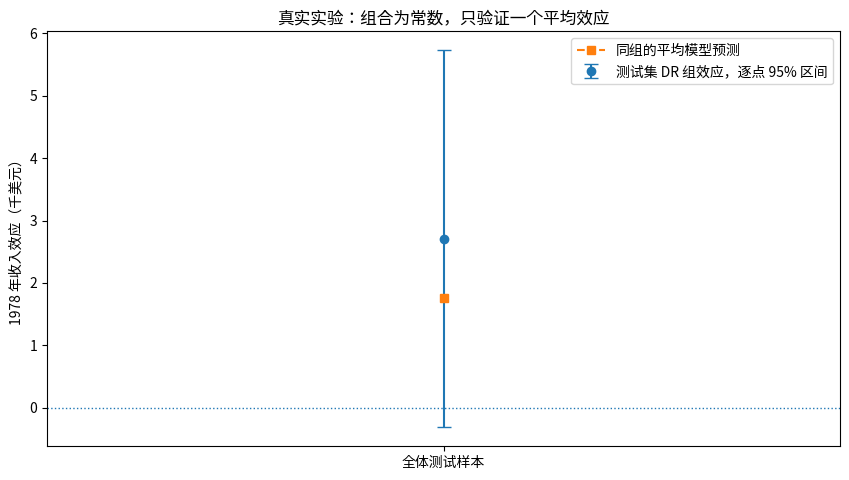

In [17]:
real_pt = predict_candidates(real_models, re)
real_f = real_pt.to_numpy() @ real_w
real_ge = dr_signal(re, predict_nuisance(fit_nuisance(pd.concat([rt, rs]), degree=1, randomized=True), re))
real_comparison = paired_loss(real_ge, real_f, real_pt["常数"])
display_p_table(pd.DataFrame([real_comparison], index=["Q组合减常数"]), ["p值"])
if real_f.std() > 1e-12:
    real_blp, _ = blp_test(real_ge, real_f)
    display_p_table(pd.DataFrame([real_blp], index=["真实实验测试集"]), ["p_b=0", "p_线性校准"])
else:
    print("Q组合为常数：BLP 斜率没有可用的预测变异，未进行该检验。")
real_cal, real_cal_metrics, real_group = calibration_table(real_ge, real_f, real_cut, re["T"])
display(real_cal.round(4))
if len(real_cal) == 2:
    high, low = real_group == 1, real_group == 0
    high_low = real_ge[high].mean()-real_ge[low].mean()
    high_low_se = np.sqrt(real_ge[high].var(ddof=1)/high.sum()+real_ge[low].var(ddof=1)/low.sum())
    print(f"高预测组减低预测组：{high_low:.3f}；95% 区间 "
          f"[{high_low-Z_CRIT*high_low_se:.3f}, {high_low+Z_CRIT*high_low_se:.3f}] 千美元")

fig, ax = plt.subplots(figsize=(8.6, 4.9))
xpos = np.arange(len(real_cal))
ax.errorbar(xpos, real_cal["DR组效应"], yerr=Z_CRIT*real_cal["SE_组效应"],
            fmt="o", capsize=5, label="测试集 DR 组效应，逐点 95% 区间")
ax.plot(xpos, real_cal["平均预测"], "s--", label="同组的平均模型预测")
ax.axhline(0, linestyle=":", linewidth=1)
real_labels = ["全体测试样本"] if len(real_cal) == 1 else [f"组 {k}" for k in real_cal["组"]]
real_title = ("真实实验：组合为常数，只验证一个平均效应" if len(real_cal) == 1
              else "真实实验：组间差异要连同不确定性解释")
ax.set(xticks=xpos, xticklabels=real_labels, ylabel="1978 年收入效应（千美元）", title=real_title)
ax.legend()
fig.tight_layout()
plt.show()

默认划分中，选择集把 Q 权重全部放在常数模型上。此时只应保留一个校准组，不人为将数值舍入误差切成高低组，也不计算没有预测变异的 BLP 斜率。

这个结果不证明培训效应恒定；它说明在本次数据划分和候选集合下，选择步骤没有支持更复杂的效应函数。更换划分可能改变赢家，但不能反复换种子直到得到显著异质性。

## 练习

### 练习一：并列分数、随机分母与 TOC 的影响值

给定一列只有三个不同数值的模型预测，先用独立参考样本确定优先 20%、50%、80% 的规则。检查边界随机化是否达到参考样本的目标比例，以及新样本实际比例是否仍恰好相同。

再给某一行增加很小的概率质量：将经验分布改成

$$
P_\epsilon=(1-\epsilon)P_n+\epsilon\delta_i.
$$

重新计算 TOC 和 QINI，比较差商与该行的影响值。这里重新计算入选比例；不是把分母固定不动。这是一项数值微分核对，不是 Bootstrap，也不是新的因果识别假设。

In [18]:
reference_ties = np.array([0., 0., 0., 0., 1., 1., 1., 2., 2., 2.])
evaluation_ties = np.array([0., 0., 1., 1., 1., 1., 2., 2., 2., 2., 2., 2.])
tie_gamma = np.array([-1., 1., -0.5, 1., 1.5, 2., 1., 2., 3., 4., 5., 6.])
tie_q = np.array([0.2, 0.5, 0.8])
h_ref, _ = threshold_policies(reference_ties, reference_ties, tie_q)
h_eval, tie_audit = threshold_policies(reference_ties, evaluation_ties, tie_q)
assert np.allclose(h_ref.mean(axis=0), tie_q)
display(tie_audit.round(4))
base_tie = uplift_statistics(tie_gamma, h_eval)

def weighted_uplift(gamma, h, probability):
    probability = np.asarray(probability, float)
    p = probability @ h
    average = probability @ gamma
    group_mean = probability @ (h*gamma[:, None])/p
    return group_mean-average, probability @ (h*gamma[:, None])-p*average


epsilon = 1e-7
micro_rows = []
for row in (0, 4, 11):
    probability = np.full(len(tie_gamma), (1-epsilon)/len(tie_gamma))
    probability[row] += epsilon
    toc_eps, qini_eps = weighted_uplift(tie_gamma, h_eval, probability)
    for j, q in enumerate(tie_q):
        micro_rows.append([row, q, (toc_eps[j]-base_tie["TOC"][j])/epsilon,
                           base_tie["phi_TOC"][row, j],
                           (qini_eps[j]-base_tie["QINI"][j])/epsilon,
                           base_tie["phi_QINI"][row, j]])
micro_check = pd.DataFrame(micro_rows, columns=["行", "q", "TOC差商", "TOC影响值", "QINI差商", "QINI影响值"])
display(micro_check.round(6))
assert np.allclose(micro_check["TOC差商"], micro_check["TOC影响值"], rtol=2e-6, atol=2e-6)
assert np.allclose(micro_check["QINI差商"], micro_check["QINI影响值"], rtol=2e-6, atol=2e-6)

,目标q,冻结阈值,边界概率,实际比例
0,0.2,2.0,0.6667,0.3333
1,0.5,1.0,0.6667,0.7222
2,0.8,0.0,0.5000,0.9167


,行,q,TOC差商,TOC影响值,QINI差商,QINI影响值
0,0,0.2,3.083333,3.083333,0.555555,0.555556
1,0,0.5,3.083333,3.083333,1.759259,1.759259
2,0,0.8,1.298209,1.298209,1.111111,1.111111
3,4,0.2,0.583333,0.583333,-0.277778,-0.277778
4,4,0.5,-0.552761,-0.552761,-0.435185,-0.435185
5,4,0.8,-0.259642,-0.259642,-0.222222,-0.222222
6,11,0.2,1.083333,1.083333,0.833333,0.833333
7,11,0.5,0.609960,0.609961,0.620370,0.620370
8,11,0.8,0.149449,0.149449,0.152778,0.152778


### 练习二：校准良好，是否就学到了异质性？

四种等概率特征类型的真实 CATE 为 $(-1,1,3,5)$。比较真函数、只区分两组的 $(0,0,4,4)$、恒定预测 2，以及放大平移后的 $2\tau+1$。

对每个模型 $f$，令 $c(f)=E[\tau(X)\mid f(X)]$，直接核对

$$
E[(f-\tau)^2]
=E[(f-c(f))^2]+E[(c(f)-\tau)^2]
=\mathrm{CAL}_2(f)+\mathrm{DIS}(f).
$$

第一项衡量同分预测是否校准，第二项衡量模型把不同效应压在同一预测值里损失了多少信息。这里按书中“均方误差分解”的含义使用平方 $L^2$ 范数；上传稿式 (15.3.6) 左侧显示的是未平方的范数，本篇不按那个字面形式计算。

这张表知道真实函数，所以能完整分解。真实数据上的分组校准图没有提供全部的 $\mathrm{DIS}$，不能凭校准图代替函数误差评价。[2，式 (15.3.3)–(15.3.7)]

,MSE,CAL2,DIS
模型,,,
真函数,0.0,0.0,0.0
两组预测,1.0,0.0,1.0
恒定预测2,5.0,0.0,5.0
放大平移,14.0,14.0,0.0


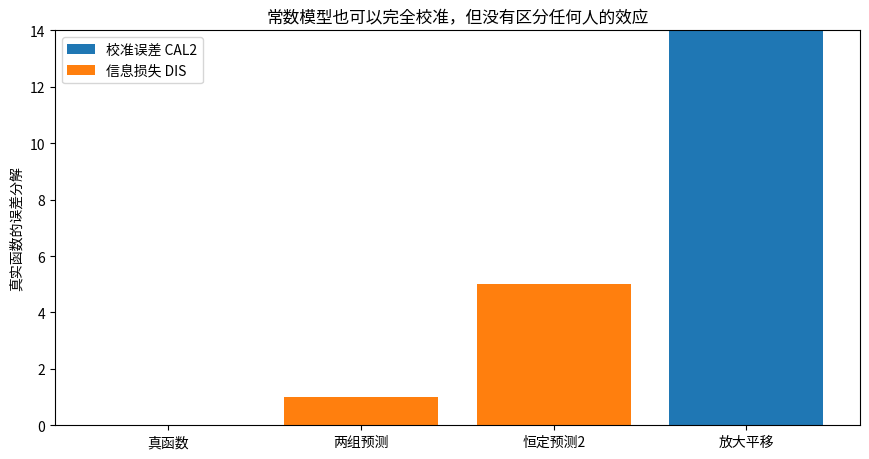

In [19]:
exercise_tau = np.array([-1., 1., 3., 5.])
exercise_models = {"真函数": exercise_tau, "两组预测": np.array([0., 0., 4., 4.]),
                   "恒定预测2": np.full(4, 2.), "放大平移": 2*exercise_tau+1}
decomposition_rows = []
for name, f in exercise_models.items():
    calibration_function = np.empty_like(f)
    for value in np.unique(f):
        calibration_function[f == value] = exercise_tau[f == value].mean()
    mse = np.mean((f-exercise_tau)**2)
    cal2 = np.mean((f-calibration_function)**2)
    distortion = np.mean((exercise_tau-calibration_function)**2)
    assert np.isclose(mse, cal2+distortion)
    decomposition_rows.append([name, mse, cal2, distortion])
decomposition = pd.DataFrame(decomposition_rows, columns=["模型", "MSE", "CAL2", "DIS"]).set_index("模型")
display(decomposition)

fig, ax = plt.subplots(figsize=(8.8, 4.7))
xpos = np.arange(len(decomposition))
ax.bar(xpos, decomposition.CAL2, label="校准误差 CAL2")
ax.bar(xpos, decomposition.DIS, bottom=decomposition.CAL2, label="信息损失 DIS")
ax.set(xticks=xpos, xticklabels=decomposition.index, ylabel="真实函数的误差分解",
       title="常数模型也可以完全校准，但没有区分任何人的效应")
ax.legend()
fig.tight_layout()
plt.show()

恒定预测 2 的校准误差为零，却抹去了全部可由特征区分的异质性。另一方面，$2\tau+1$ 完整保留排序，却在数值上严重失准。校准、排序和平方误差要分开报告。

## 总结与适用范围

模型比较先固定候选，再在独立数据上用同一列 DR 信号计算逐行损失差。选择集能选赢家，也能拟合组合，但不能兼任最终检验集。最后的模型、方向、分组切点和预算网格都需要在测试结局之外确定。

BLP 检验回答是否存在与预测相关的异质性；分组校准检查预测尺度；TOC、QINI 检查优先排序相对于随机分配同等覆盖比例的收益。它们都不是对个人反事实标签的直接检验。一个模型可以通过其中一项而不通过另一项。

本篇的同时区间针对固定网格与固定阈值规则。若要求在部署人群中恰好选最高的某个比例，分位数估计误差也需纳入推断；原书将这种排序解释另行讨论，本篇没有把两种问题混在一起。[2，Remark 15.3.2]

观察性数据仍依赖未测混杂、重叠和数据质量等识别条件。模型预测在新样本上表现稳定，并不证明这些假设成立。真实案例的宽区间、模拟中的选择波动，都应作为结果保留，而不是继续调参直到验证“成功”。

## 参考资料

[1] Peng Ding. *A First Course in Causal Inference*. 上传版本：arXiv:2305.18793v2，2023-10-03。第 2、10、12 章用于潜在结局、识别与 AIPW；第 3.4 节使用 LaLonde 实验数据。

[2] Victor Chernozhukov, Christian Hansen, Nathan Kallus, Martin Spindler, Vasilis Syrgkanis. *Applied Causal Inference Powered by ML and AI*. 上传版本：2026-05-03，Version 0.1.2。第 15.2、15.3 节（PDF 第 427–451 页，正文第 417–441 页）是本篇主体。只展开其中的评分、简单组合、BLP、分组校准与固定规则 uplift；不复现其 Welfare、401(k) 或数字广告结果，也不在本篇实现最优策略学习。

版本与实现说明：式 (15.3.6) 按正文“均方误差”解释写为平方范数；式 (15.3.10)–(15.3.11) 的人数加权总和与除以总人数的平均量分别标明；TOC 使用测试集估计分母的比值影响值，其与定理 15.3.1 显示信号的差异在正文列出并经数值微分核对。并列分数按随机化规则的实际期望权重统一计算分母，避免重复计入边界人数。以上是本篇明确给出的实现口径，不声称上传稿逐式原样如此。

[3] statsmodels. `OLSResults.get_robustcov_results`，HC1 协方差与 `use_t=False` 的正态推断。https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLSResults.get_robustcov_results.html 。本次实际版本在初始化和 Notebook 元数据中记录。

[4] SciPy. `minimize(method='SLSQP')`。https://docs.scipy.org/doc/scipy/reference/optimize.minimize-slsqp.html 。用于有单纯形约束的凸组合与 Q-aggregation；提供显式梯度并检查求解状态。

[5] scikit-learn. `HistGradientBoostingRegressor`。https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingRegressor.html 。本篇固定超参数并关闭自动 early stopping；只在训练数据中拟合候选模型。

[6] Matching 包的 `lalonde` 数据。数据说明见 https://rdrr.io/cran/Matching/man/lalonde.html 。本篇复用第十份笔记已核对的数据快照，仅提取 NSW 实验组与实验对照，保留 445 人；压缩前 CSV 的 SHA-256 写在数据单元。本篇的拆分、模型、结局单位与第十份完整案例不同，不把局部测试结果当成对全样本估计的数值复现。